# LLM Fine-Tuning Deep Dive, Part 1 of 3: What Should the Model Learn?

> **The story:** Riverside changes the model's training experience to teach three different behaviors: continued pretraining practices its prose, SFT practices an assistant contract, and DPO practices editorial preference.
>
> **Where you are:** The transformer chapters explained next-token prediction. Part 1 builds intuition for **what behavior the examples teach**; Part 2 explores **where the update is stored**; Part 3 asks what independent evidence supports.

## Meet Riverside and Aria

> **Fictional corpus context:** This notebook uses Riverside House's complete 40-chapter generation-ship novel *The Weight of Distant Light*. Aria Voss is a Systems Maintenance technician aboard the *Meridian's Promise* whose discovery of an artificial prime-number signal begins the novel's first-contact arc with the ancient distributed intelligence later known as the Choir.

All 40 chapters supply teaching examples. That gives the tiny, compute-bounded model the strongest available signal and keeps this notebook focused on how each objective works. The next section explains why these mechanism demonstrations deliberately do not use a holdout.

## Why Riverside Is Even Considering Fine-Tuning

Riverside House already has capable general-purpose models. The problem is repetition.

For every new scene, jacket blurb, launch email, or character campaign, an editor has to restate the same private context:

- Aria's voice is precise, curious, and technically grounded.
- The *Meridian's Promise*, Wren, the Lantern, and the Choir have established relationships.
- House copy should be concise and should stop when the requested unit is complete.
- A useful draft advances the work instead of paraphrasing the brief.

Longer prompts can carry those reminders, but the reminders consume context, drift between editors, and still require the same corrections. Riverside is exploring fine-tuning because some behavior is valuable precisely when it becomes the model's **default starting habit**, not another paragraph pasted into every request.

### What Fine-Tuning Could Buy Riverside

| Repeated Riverside cost | Persistent behavior worth teaching | Business value |
| --- | --- | --- |
| Editors repeatedly explain voice, characters, and continuity | Recognize Riverside prose patterns and recurring story relationships | Faster first drafts with fewer continuity corrections |
| Every workflow repeats formatting and stopping rules | Follow a stable request/response contract | Less prompt boilerplate and less cleanup |
| Valid drafts still vary in editorial usefulness | Prefer drafts that advance the scene and respect house taste | Fewer low-value revisions before human editing |
| Manuscripts cannot be sent to a public training API | Adapt a local checkpoint on private text | Preserve confidentiality and operational control |

Fine-tuning is not automatically the answer:

- **Prompting first:** use it when a clear instruction or a few examples already produce the needed behavior.
- **RAG:** use it for changing HR policies, legal terms, contracts, benefits, catalogs, and other facts that must remain current, citable, deletable, and permission-filtered.
- **Fine-tuning:** explore it when the same stable behavior should recur across many requests without restating the entire house playbook.
- **Fine-tuning plus RAG:** combine a durable Riverside persona or workflow with current approved evidence.

Fine-tuning is a poor database. RAG is a poor substitute for learned voice and habits. Riverside needs both only when the product needs both persistent behavior and changing facts.

### The Three Riverside Experiments

Use one Aria scene to see how the teaching signal changes:

| Experiment | What Riverside shows the model | Habit Riverside hopes to teach |
| --- | --- | --- |
| **1. Rehearse the story world** | Raw manuscript scenes where Aria, Wren, and the *Meridian's Promise* appear naturally | Riverside names, relationships, and prose should feel expected rather than unfamiliar |
| **2. Practice the editor's contract** | Request: `Continue this scene in exactly one sentence and stop.` Response: one approved sentence | Answer the requested unit, then stop instead of continuing indefinitely |
| **3. Practice the editor's choice** | Same request, two valid one-sentence drafts; the editor marks the scene-advancing draft as preferred | Favor a useful next move over a grammatical sentence that merely repeats the setup |

```text
raw scene                         -> learn what Riverside prose looks like
request + approved response       -> learn how Riverside wants an answer shaped
request + preferred/rejected pair -> learn which valid answer Riverside would choose
```

The data changes because the lesson changes. This notebook opens those three training mechanisms; Part 3 later asks whether independent evidence shows that any resulting artifact actually learned the intended habit.

## Why This Notebook Uses All 40 Chapters

Part 1 is a **mechanism demonstration**, not a capability study. Its question is: *what does each objective do with its examples?* The tiny model, one short novel, and ten-step CPU runs are deliberately sized to expose tokenization, labels, gradients, adapters, and saved artifacts rather than establish generalization.

That creates a deliberate tradeoff:

| Choice in Part 1 | What it helps us see | What it prevents us from claiming |
| --- | --- | --- |
| Use all 40 chapters to build training examples | Give each short run the strongest available teaching signal and make every objective easy to inspect | We cannot call later samples held-out evidence or claim the model learned unseen Riverside behavior |
| Run only ten optimizer steps on a small checkpoint | Keep the complete training path runnable and observable on ordinary hardware | We cannot interpret prose quality as production capability |

So every generated sample in this notebook is an **in-sample illustration**: useful for understanding the training mechanism, insufficient for deciding whether the artifact is good. A genuine capability claim needs examples that played no role in training-data construction, checkpoint selection, prompt tuning, or threshold setting.

Part 3 owns that evidence boundary. It requires a separately versioned evaluation suite, compares each candidate with the appropriate baseline, and applies gates chosen before results are inspected.

| Part | Question |
| --- | --- |
| 1 - this notebook | What training experience teaches the desired behavior? |
| [2 - parameter strategy](02-llm-finetuning-parameter-techniques.ipynb) | Where can that update live, and what does each mechanism change? |
| [3 - evaluation and decision](03-llm-finetuning-comparison-and-decision.ipynb) | What does independent evidence support? |

Continued pretraining and SFT start from separate pinned base models; the preference stage continues from the SFT adapter. Checkpoints and training-provenance manifests are written under `checkpoints/llm-finetuning/<profile>/`.

> **Boundary:** fine-tuning changes persistent behavior. A later retrieval chapter supplies current, citable facts.

## Fine-Tuning Roadmap: Start Here

Read the arc vertically: Part 1 changes the learning objective, Part 2 changes the parameter mechanism, and Part 3 introduces evidence and decisions.

```mermaid
flowchart TD
    Start["Pinned SmolLM2<br/>fluent, but unfamiliar with Riverside"]

    subgraph Data["Part 1 - choose the learning objective"]
        direction TB
        C1["Continued pretraining<br/>practice Riverside prose"]
        C2["SFT<br/>practice a request/response contract"]
        C3["Preference alignment<br/>practice chosen over rejected"]
        C1 --> C2 --> C3
    end

    subgraph Params["Part 2 - choose the parameter mechanism"]
        direction TB
        C4["Full fine-tuning"]
        C5["Partial freezing"]
        C6["LoRA"]
        C7["QLoRA + quantization"]
        C4 --> C5 --> C6 --> C7
    end

    Start --> C1
    C3 --> Saved["Training artifacts<br/>full 40-chapter corpus"]
    Saved --> C4
    C7 --> Evaluate["Part 3<br/>metrics, comparison, gates, decisions"]
```

> The arrows are a learning sequence, not literal checkpoint ancestry. Parts 1 and 2 demonstrate mechanisms on the complete corpus; only Part 3 may interpret measurements or make decisions.

## Prerequisite Bridge: From Encoder-Decoder Attention to a Decoder-Only Assistant

The transformer foundations introduced three useful shapes: an **encoder** reads an entire input, a **decoder** predicts the next token while respecting a causal mask, and an **encoder-decoder** model lets a decoder attend to an encoded source through cross-attention. Riverside's assistant uses the decoder-only choice: at each turn, the user's instruction, any supplied scene, and the completion form one growing token sequence.

| Foundation | Role in this chapter | Why Riverside needs it |
| --- | --- | --- |
| Causal decoder | The selected SmolLM2 profile predicts the next token | It can continue prose and answer prompts from one left-to-right context |
| Training objective | Labels say which next tokens should become more likely | Continued pretraining, SFT, and preference learning change what Riverside teaches the decoder |
| Encoder / retrieval later | Encodes a query and passages for matching | It finds current, citable evidence instead of asking the generator to remember every fact |

So this notebook changes **how a decoder-only model behaves**. It does not turn the model into a dependable catalog lookup system.

The underlying mechanics are owned by the prerequisite notebooks:

- [Transformers Part 12](../01-transformers/02-decoder-only-language-model.ipynb#part-12---the-causal-triangle-and-the-accumulation-tower) explains causal visibility.
- [Transformers Part 8](../01-transformers/02-decoder-only-language-model.ipynb#part-8---mini-language-model-training--inference) owns decoder-only training, including the [per-position loss microscope](../01-transformers/02-decoder-only-language-model.ipynb#per-position-loss-one-sequence-many-lessons) and [one complete backward/update trace](../01-transformers/02-decoder-only-language-model.ipynb#one-backward-pass-many-token-lessons-one-update).
- [PyTorch RNN Bridge Part 4](../../genai-prerequisites/07-pytorch-rnn-bridge/01-pytorch-rnn-bridge.ipynb#part-4--explicit-sequence-training-and-gradient-clipping) owns shifted sequence loss, backpropagation, and optimizer mechanics.
- [Encoder-Decoder Part 5](../01-transformers/03-encoder-decoder-and-cross-attention.ipynb#part-5--full-encoder-decoder-training) owns teacher-forced seq2seq training and cross-attention.

This notebook assumes those mechanics and focuses on the fine-tuning decision: **which examples and labels teach the behavior Riverside needs?**

> **Implementation preview:** the objective and parameter strategy are separate choices. This notebook uses full fine-tuning for the continued-pretraining demonstration, then small LoRA adapters for SFT and the final preference update so the runs fit local hardware. Treat LoRA here as a small trainable correction attached to a frozen base; Part 2 opens that black box and compares it with full and partial fine-tuning.

## Learning Route

1. Pin the base revision, seed, artifact paths, and complete Aria corpus.
2. Build raw-text examples and inspect how continued pretraining labels every real token.
3. Build request/response demonstrations and inspect response-only SFT masking.
4. Build chosen/rejected comparisons and develop PPO-versus-DPO intuition.
5. Run each short training mechanism and save training-provenance artifacts.
6. Continue to Part 2 for full, frozen, LoRA, and QLoRA parameter intuition.
7. Continue to Part 3, where evaluation begins.

**Optional depth:** token-level mechanics live in the prerequisite notebooks linked below. The resumable-job appendix packages the same full-corpus training paths without interpreting the resulting behavior.

In [78]:
from pathlib import Path

# Resolve repository-owned corpus and checkpoint paths independently of kernel cwd.
def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "learning" / "genai" / "content").is_dir() and (candidate / "checkpoints").is_dir():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from the repository or a descendant directory; "
        "expected learning/genai/content and checkpoints at the repository root."
    )


REPO_ROOT = find_repo_root()
CONTENT_DIR = REPO_ROOT / "learning" / "genai" / "content"
CHECKPOINT_DIR = REPO_ROOT / "checkpoints"
ARIA_NOVEL_DIR = CONTENT_DIR / "the-weight-of-distant-light"

if not ARIA_NOVEL_DIR.exists():
    raise FileNotFoundError(
        f"Could not find the shared Aria corpus at {ARIA_NOVEL_DIR}. "
        "Expected the GenAI-wide corpus under learning/genai/content."
    )

ARIA_CHAPTER_FILES = sorted(ARIA_NOVEL_DIR.glob("chapter-*.txt"))
if not ARIA_CHAPTER_FILES:
    raise ValueError("The Aria corpus does not contain any chapter files")

# This compute-bounded concept notebook uses every available chapter for training.
ARIA_TRAIN_FILES = ARIA_CHAPTER_FILES


def load_paragraphs(chapter_files, min_len=200):
    """Load qualifying paragraphs from explicit, provenance-preserving chapter files."""
    paragraphs = []
    for path in chapter_files:
        text = path.read_text(encoding="utf-8")
        for paragraph in text.split("\n\n"):
            paragraph = paragraph.strip().replace("\n", " ")
            if len(paragraph) >= min_len:
                paragraphs.append(paragraph)
    return paragraphs


sample_paragraphs = load_paragraphs(ARIA_TRAIN_FILES[:2])
print(f"Aria corpus used for training: {len(ARIA_TRAIN_FILES)} chapters")
print(f"Shared content: {CONTENT_DIR}")
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"First training paragraph:\n\n{sample_paragraphs[0][:421]} ...")


Aria corpus used for training: 40 chapters
Shared content: c:\r\ai-portfolio\learning\genai\content
Checkpoints: c:\r\ai-portfolio\checkpoints
First training paragraph:

Aria Voss had learned to listen to the ship the way other people listened to weather. Two hundred and fourteen years after the Meridian's Promise had folded its sails of solar canvas and slipped away from the blue marble of Earth, the great vessel still spoke in a thousand small voices, and Aria had spent her whole life learning to tell them apart. The groan of the spinward bearings when the ring decks turned through  ...


## Motivation: See the Starting Behavior Before Naming a Technique

Riverside begins with three distinct behavior gaps:

| Behavior gap | Illustrative request | What the example reveals |
| --- | --- | --- |
| Unfamiliar domain prose | Continue a passage containing Riverside-only names and relationships | The model can write fluent English while inventing the story world |
| Unpracticed response contract | `Answer in one sentence and stop.` | General instruction ability does not guarantee this exact house workflow |
| Unexpressed editorial preference | Compare two valid answers to the same request | Demonstrations alone do not state which valid draft an editor prefers |

Start with the prose gap. The base model has never seen Riverside's manuscripts, so names in a prompt can guide a plausible guess without installing the recurring relationships or style.

That motivates the first training experience:

> The model already practices English; continued pretraining lets it practice Riverside text.

---

### Setting Up the Shared Teaching Model

The three sections use pinned checkpoints and objective-specific fixed probes so each before/after mechanism comparison remains reproducible.

### Pick Capacity From the Hardware, Keep the Objective Fixed

The notebook chooses a matched base/instruction pair from one model family:

| Runtime | Continued-pretraining base | SFT/DPO base | Purpose |
| --- | --- | --- | --- |
| CPU | `HuggingFaceTB/SmolLM2-135M` | `HuggingFaceTB/SmolLM2-135M-Instruct` | Keep every mechanism runnable on ordinary hardware. |
| CUDA below 64 GiB | `HuggingFaceTB/SmolLM2-360M` | `HuggingFaceTB/SmolLM2-360M-Instruct` | Give a typical GPU a stronger baseline without making the multi-model comparison impractical. |
| CUDA with at least 64 GiB | `HuggingFaceTB/SmolLM2-1.7B` | `HuggingFaceTB/SmolLM2-1.7B-Instruct` | Prefer the strongest same-family teaching checkpoint when memory supports the complete arc. |

The objective, prompt contract, LoRA targets, data split, and evidence gates do not change between profiles. Artifacts are written to a profile-specific directory because adapters and full checkpoints cannot be moved safely between model sizes.

In [79]:
import hashlib
import json
import random
from importlib.metadata import version

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

CUDA_AVAILABLE = torch.cuda.is_available()
GPU_MEMORY_GIB = (
    torch.cuda.get_device_properties(0).total_memory / 1024**3 if CUDA_AVAILABLE else 0.0
)

if not CUDA_AVAILABLE:
    MODEL_PROFILE = "cpu-small-135m"
    CPT_MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"
    CPT_MODEL_REVISION = "93efa2f097d58c2a74874c7e644dbc9b0cee75a2"
    INSTRUCT_MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"
    INSTRUCT_MODEL_REVISION = "12fd25f77366fa6b3b4b768ec3050bf629380bac"
elif GPU_MEMORY_GIB < 64:
    MODEL_PROFILE = "gpu-balanced-360m"
    CPT_MODEL_NAME = "HuggingFaceTB/SmolLM2-360M"
    CPT_MODEL_REVISION = "f8027fd0eaeea54caa13c31d31b9fdc459c38b49"
    INSTRUCT_MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"
    INSTRUCT_MODEL_REVISION = "a10cc1512eabd3dde888204e902eca88bddb4951"
else:
    MODEL_PROFILE = "gpu-quality-1.7b"
    CPT_MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B"
    CPT_MODEL_REVISION = "effd688a12921b4cc83e3312b6feb579f70f9c71"
    INSTRUCT_MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B-Instruct"
    INSTRUCT_MODEL_REVISION = "31b70e2e869a7173562077fd711b654946d38674"

MODEL_NAME = INSTRUCT_MODEL_NAME
MODEL_REVISION = INSTRUCT_MODEL_REVISION
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]
EXPERIMENT_SEED = 2026
DEMO_TRAIN_STEPS = 10
DEMO_DPO_STEPS = 10
CPU_BUDGET_MINUTES = 360
GPU_BUDGET_MINUTES = 20

PROFILE_CHECKPOINT_DIR = CHECKPOINT_DIR / "llm-finetuning" / MODEL_PROFILE
CPT_CHECKPOINT_DIR = PROFILE_CHECKPOINT_DIR / "non-instruction-full"
SFT_CHECKPOINT_DIR = PROFILE_CHECKPOINT_DIR / "instruction-lora"
DPO_CHECKPOINT_DIR = PROFILE_CHECKPOINT_DIR / "preference-dpo"

random.seed(EXPERIMENT_SEED)
set_seed(EXPERIMENT_SEED)


def _file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def write_artifact_manifest(
    stage,
    output_dir,
    training_files,
    training_args,
    extra=None,
    model_name=MODEL_NAME,
    model_revision=MODEL_REVISION,
):
    """Record immutable model, full-corpus, package, and training provenance beside an artifact."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    manifest = {
        "stage": stage,
        "model_profile": MODEL_PROFILE,
        "model": {"id": model_name, "revision": model_revision},
        "seed": EXPERIMENT_SEED,
        "training_files": [
            {"path": path.relative_to(REPO_ROOT).as_posix(), "sha256": _file_sha256(path)}
            for path in training_files
        ],
        "training_arguments": training_args.to_dict(),
        "packages": {
            package: version(package)
            for package in ("torch", "transformers", "datasets", "peft", "trl")
        },
        "extra": extra or {},
    }
    manifest_path = output_dir / "experiment-manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding="utf-8")
    print(f"Wrote provenance manifest: {manifest_path}")
    return manifest_path


training_budget_minutes = GPU_BUDGET_MINUTES if CUDA_AVAILABLE else CPU_BUDGET_MINUTES
print(f"Model profile: {MODEL_PROFILE}")
print(f"CUDA memory: {GPU_MEMORY_GIB:.1f} GiB")
print(f"CPT model: {CPT_MODEL_NAME}@{CPT_MODEL_REVISION[:8]}")
print(f"SFT/DPO model: {INSTRUCT_MODEL_NAME}@{INSTRUCT_MODEL_REVISION[:8]}")
print(f"Profile checkpoints: {PROFILE_CHECKPOINT_DIR}")
print(f"Training budget on this device: {training_budget_minutes} minutes")
if not CUDA_AVAILABLE:
    print(
        "CPU disclaimer: the 135M model and ten-step runs are for learning the training "
        "mechanisms, not for demonstrating production-quality prose or generalization."
    )

Model profile: cpu-small-135m
CUDA memory: 0.0 GiB
CPT model: HuggingFaceTB/SmolLM2-135M@93efa2f0
SFT/DPO model: HuggingFaceTB/SmolLM2-135M-Instruct@12fd25f7
Profile checkpoints: c:\r\ai-portfolio\checkpoints\llm-finetuning\cpu-small-135m
Training budget on this device: 360 minutes
CPU disclaimer: the 135M model and ten-step runs are for learning the training mechanisms, not for demonstrating production-quality prose or generalization.


### How to Read the Small CPU Run

The 135M CPU profile is intentionally mechanism-sized. Ten updates are enough to expose tokenization, masking, gradients, adapters, trainer state, and checkpoint boundaries, but not enough to establish behavior beyond the exercise.

Treat every generated sample in Parts 1 and 2 as an intuition-building illustration from a model trained on the complete corpus. Evaluation begins in Part 3.

### Training Controls Come After the Mechanisms

The short runs below show only the settings needed to interpret each objective. After CPT, SFT, and DPO are visible, **[Tunable Parameters] How Training Controls Reach the Output** brings the shared controls together, explains their failure modes, and separates objective settings from parameter-strategy settings.


> **PyTorch → Keras:** `torch.cuda.is_available()` — checks whether a CUDA-capable GPU is visible to PyTorch and returns a bool; the result picks the `device` string (`"cuda"` or `"cpu"`) that every tensor and model call below is pinned to via `.to(device)`. **Keras/TF equivalent:** `tf.config.list_physical_devices('GPU')` — TensorFlow auto-places ops on any visible GPU without needing an explicit device string threaded through the code, so most Keras code skips this check entirely; `tf.device(...)` exists for the rare case you want to force placement.

In [80]:
device = "cuda" if CUDA_AVAILABLE else "cpu"
print(f"Using device: {device} ({MODEL_PROFILE})")

Using device: cpu (cpu-small-135m)


### Loading the Tokenizers

Continued pretraining and instruction-tuned generation use different checkpoints, so each path loads the tokenizer pinned to its own model revision. The selected SmolLM2 checkpoints share a 49,152-token vocabulary, and their EOS token also serves as the padding token.

This section stays at the token level: how text becomes IDs, why whitespace changes token boundaries, and how padding is excluded from loss. Role-based instruction prompts and response-only supervision begin in the SFT section.

> **PyTorch → Keras:** `AutoTokenizer.from_pretrained(...)` loads the same checkpoint-matched tokenizer for either framework. Tokenization is framework-agnostic; the split between PyTorch and TensorFlow begins when the resulting arrays become framework tensors.

In [81]:
# Load the tokenizer pinned to each model path before comparing their token contracts.
cpt_tokenizer = AutoTokenizer.from_pretrained(
    CPT_MODEL_NAME,
    revision=CPT_MODEL_REVISION,
)
if cpt_tokenizer.pad_token is None:
    cpt_tokenizer.pad_token = cpt_tokenizer.eos_token

tokenizer = AutoTokenizer.from_pretrained(
    INSTRUCT_MODEL_NAME,
    revision=INSTRUCT_MODEL_REVISION,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"CPT tokenizer vocabulary: {len(cpt_tokenizer):,}")
print(f"CPT EOS/pad: {cpt_tokenizer.eos_token!r} / {cpt_tokenizer.pad_token!r}")
print(f"Instruction-checkpoint tokenizer vocabulary: {len(tokenizer):,}")
print(f"Instruction-checkpoint EOS/pad: {tokenizer.eos_token!r} / {tokenizer.pad_token!r}")

CPT tokenizer vocabulary: 49,152
CPT EOS/pad: '<|endoftext|>' / '<|endoftext|>'
Instruction-checkpoint tokenizer vocabulary: 49,152
Instruction-checkpoint EOS/pad: '<|im_end|>' / '<|im_end|>'


### Seeing the Vocabulary in Action

Byte-level BPE can represent arbitrary text, but common spans receive compact tokens while rare names or
unusual Unicode sequences split into several pieces. Whitespace is context: tokenizing `"signal"` and
`" signal"` can produce different IDs because a space may be merged with neighboring bytes.

The code below prints IDs, raw tokenizer tokens, and decoded pieces for each example. Decoding each ID is
the portable way to make spaces and newlines visible; raw token strings are implementation details and
should not be treated as a universal notation.


> **PyTorch → Keras:** `tokenizer.encode(word)` / `tokenizer.convert_ids_to_tokens(ids)` — converts raw text to integer token IDs (and back to readable BPE-piece strings) using the framework-agnostic tokenizer loaded above; no tensors are created yet, just plain Python lists. **Keras/TF equivalent:** identical call — `AutoTokenizer` isn't PyTorch- or TF-specific, so a Keras/TF version of this notebook would use this exact same code; only the downstream model call (`TFAutoModelForCausalLM` vs. `AutoModelForCausalLM`) would differ.

In [82]:
# One example each of a noun, proper noun, verb, and adjective -- all pulled from Riverside's own
# sci-fi opening line, so these are words this notebook already leans on elsewhere.
example_words = {
    "noun": "signal",
    "proper noun": "Aria",
    "verb": "stared",
    "adjective": "distant",
}

for part_of_speech, word in example_words.items():
    ids_alone = tokenizer.encode(word)  # tokenize the word standalone (no leading space)
    ids_mid_sentence = tokenizer.encode(" " + word)  # tokenize as it would appear mid-sentence
    print(f"{part_of_speech.upper()}: {word!r}")
    print(
        f"  as the first word of a text  : ids={ids_alone}  "
        f"tokens={tokenizer.convert_ids_to_tokens(ids_alone)}"
    )
    print(
        f"  mid-sentence (' {word}')".ljust(31) + f": ids={ids_mid_sentence}  "
        f"tokens={tokenizer.convert_ids_to_tokens(ids_mid_sentence)}"
    )
    print()

print(
    "'\u0120' at the start of a token marks a leading space -- it's why the same word can tokenize "
    "differently depending on where it appears in a sentence."
)


NOUN: 'signal'
  as the first word of a text  : ids=[21164]  tokens=['signal']
  mid-sentence (' signal')     : ids=[4973]  tokens=['Ġsignal']

PROPER NOUN: 'Aria'
  as the first word of a text  : ids=[49, 5484]  tokens=['A', 'ria']
  mid-sentence (' Aria')       : ids=[330, 5484]  tokens=['ĠA', 'ria']

VERB: 'stared'
  as the first word of a text  : ids=[302, 1214]  tokens=['st', 'ared']
  mid-sentence (' stared')     : ids=[328, 1214]  tokens=['Ġst', 'ared']

ADJECTIVE: 'distant'
  as the first word of a text  : ids=[8184, 403]  tokens=['dist', 'ant']
  mid-sentence (' distant')    : ids=[9931]  tokens=['Ġdistant']

'Ġ' at the start of a token marks a leading space -- it's why the same word can tokenize differently depending on where it appears in a sentence.


> **You may wonder:** since `Aria` splits into two tokens and appears constantly in this corpus, why
> not just train the tokenizer on Riverside's own text and merge it into a dedicated token? Two
> reasons this is out of scope for fine-tuning: extending the vocabulary adds a new, untrained row
> to the embedding matrix and output head, and filling that row in with a meaningful representation
> is itself a training problem, not something fine-tuning does for free. And splitting `Aria` into
> two tokens doesn't stop the model from learning what it means -- it can still learn to associate
> that two-token pattern with everything fine-tuning teaches it about her; it just costs two sequence
> positions instead of one, a small efficiency tax, not a correctness problem. The actual gap the
> rest of this notebook closes is that the model has never seen who Aria Voss is, not how her name
> happens to be tokenized.



> **A related question:** what happens with a word the tokenizer has rarely encountered? Byte-level
> BPE does not need an unknown-word vocabulary entry: when no longer merge matches, it falls back to smaller
> byte-derived pieces. An uncommon name such as `Itzpapalotl` therefore remains representable, although it
> usually consumes more tokens than a frequent word. Fine-tuning can improve how the model uses that sequence,
> but it does not add a new vocabulary row unless the tokenizer and embedding matrix are explicitly resized.


### Loading the Base Model

`base_model` is the actual pretrained neural network -- a checkpoint-defined number of real weights downloaded from the
Hugging Face hub, moved onto whichever device we resolved above via `.to(device)`. This untouched
checkpoint is the "before" every fine-tuning technique in this notebook is compared against.


> **PyTorch → Keras:** `AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)` — downloads the weights selected by `MODEL_NAME` into a PyTorch `nn.Module` and moves every parameter tensor onto `device` (CPU or GPU) in place. **Keras/TF equivalent:** `TFAutoModelForCausalLM.from_pretrained(MODEL_NAME)` — loads the same checkpoint into a `tf.keras.Model` instead; TensorFlow doesn't need an explicit `.to(device)` call since ops are placed on available devices automatically (or via a `tf.device(...)` context).

In [83]:
# Load the untouched instruction baseline used by SFT, DPO, and general-knowledge probes.
base_model = AutoModelForCausalLM.from_pretrained(
    INSTRUCT_MODEL_NAME,
    revision=INSTRUCT_MODEL_REVISION,
).to(device)
model_parameter_count = sum(parameter.numel() for parameter in base_model.parameters())
decoder_blocks = base_model.model.layers
n_blocks = len(decoder_blocks)
hidden_size = base_model.config.hidden_size
print(
    f"Loaded {INSTRUCT_MODEL_NAME}@{INSTRUCT_MODEL_REVISION[:8]}: "
    f"{model_parameter_count:,} parameters, {n_blocks} decoder blocks, "
    f"hidden size {hidden_size}."
)

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3182.56it/s]

Loaded HuggingFaceTB/SmolLM2-135M-Instruct@12fd25f7: 134,515,008 parameters, 30 decoder blocks, hidden size 576.


### A Reusable `generate()` Helper

Hugging Face returns the prompt and completion in one token sequence. The helper records the prompt length, slices `output[prompt_length:]`, and decodes only the new tokens so every comparison shows the model's actual continuation.

It also calls `.strip()` because the first generated token may carry leading whitespace. All later candidates use this same helper, so output formatting cannot masquerade as a model difference.

> **Scope guardrail:** Every generated continuation in Part 1 uses a fixed probe shaped for that objective and remains an **in-sample mechanism demonstration**, not evidence of capability on unseen data.

> **PyTorch → Keras:** `model.eval()` / `torch.no_grad()` / `model.generate()` — `.eval()` switches dropout/batchnorm-style layers to inference mode, `torch.no_grad()` disables gradient tracking to save memory during inference, and `.generate()` runs HuggingFace's autoregressive sampling loop (nucleus sampling here via `top_p`/`temperature`). **Keras/TF equivalent:** `TFAutoModelForCausalLM.generate()` — the same HuggingFace `.generate()` API exists on TF models with identical sampling arguments; TF's analog of "eval mode" is passing `training=False` (implicit inside `.generate()`), and there's no separate "no_grad" context since calling a `tf.keras.Model` outside a `GradientTape` block already skips gradient recording.

In [ ]:
def generate(model, prompt, tokenizer_to_use, max_new_tokens=60, seed=EXPERIMENT_SEED):
    """Generate only the new continuation tokens with a checkpoint-matched tokenizer."""
    model.eval()
    inputs = tokenizer_to_use(prompt, return_tensors="pt").to(device)
    prompt_length = inputs["input_ids"].shape[1]

    # Reset the sampler before every call so before/after comparisons start from
    # the same random state. Different text then reflects different model logits.
    set_seed(seed)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.9,
            temperature=0.8,
            pad_token_id=tokenizer_to_use.pad_token_id,
        )

    # Hugging Face returns [prompt tokens | new tokens]. Decode only the new side.
    completion = tokenizer_to_use.decode(
        output[0][prompt_length:],
        skip_special_tokens=True,
    ).strip()
    return completion or "[model stopped immediately: sampled EOS as its first token]"


### Pick Capacity From the Hardware, Keep the Objective Fixed

The notebook chooses a matched base/instruction pair from one model family:

| Runtime | Continued-pretraining base | SFT/DPO base | Purpose |
| --- | --- | --- | --- |
| CPU | `HuggingFaceTB/SmolLM2-135M` | `HuggingFaceTB/SmolLM2-135M-Instruct` | Keep every mechanism runnable on ordinary hardware. |
| CUDA below 64 GiB | `HuggingFaceTB/SmolLM2-360M` | `HuggingFaceTB/SmolLM2-360M-Instruct` | Expose the same mechanisms with a larger model. |
| CUDA with at least 64 GiB | `HuggingFaceTB/SmolLM2-1.7B` | `HuggingFaceTB/SmolLM2-1.7B-Instruct` | Use the strongest same-family teaching checkpoint when memory permits. |

The objective, prompt contract, LoRA targets, complete-corpus policy, and training steps do not change between profiles. Artifacts are written to a profile-specific directory because adapters and full checkpoints cannot move safely between model sizes.

### Transformer Mechanics Live Upstream

A causal-LM training batch follows one compact contract: token IDs enter the decoder, each position predicts the next token, padding labels use `-100`, and backpropagation updates whichever parameters remain trainable.

This chapter does not re-derive that contract. Use the prerequisite links above for causal masks, per-position cross-entropy, gradient flow, and optimizer updates. From here onward, every code path answers a training question:

- Which Riverside text becomes continued-pretraining data?
- Which prompt tokens must SFT hide from the loss?
- Which chosen/rejected pairs express editor preference?
- Which model state is saved for the next chapter?

The next section begins at that fine-tuning-specific boundary.

In [86]:
# Shared analysis imports used by later fine-tuning diagnostics.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch.nn.functional as F

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
sns.set_theme(style="whitegrid", palette="muted")

print("Shared analysis libraries loaded.")

Shared analysis libraries loaded.


---

## Choose the Training Objective From the Required Behavior

Each methodology supplies a different training experience. Choose the one whose examples most closely resemble what the production model must practice; do not build a mandatory technique chain.

| Required persistent behavior | Training experience | Riverside example | Other examples |
| --- | --- | --- | --- |
| Absorb recurring language, entities, and prose patterns | Continued pretraining on raw domain text | Practice Aria, Wren, the Choir, and Riverside's narrative style | Medical terminology, source-code conventions, specialist jargon |
| Follow a repeatable request/response contract | SFT on demonstrations | Continue a scene in exactly one sentence and stop | Structured extraction, support templates, campaign copy in a brand persona |
| Prefer one valid answer over another | DPO on chosen/rejected pairs | Advance the scene instead of restating it | Prefer concise edits, safer refusals, or editor-approved tone |
| Learn from outcomes produced by the changing model | PPO with fresh rollouts and feedback | Not needed for Riverside's fixed pair dataset | Tool-use success, simulator reward, live environment outcomes |

```mermaid
flowchart TD
    Need["Behavior the model must practice"] --> Kind{"What kind of training signal matches it?"}
    Kind -->|"raw domain sequence"| CPT["Continued pretraining"]
    Kind -->|"demonstrated response"| SFT["SFT"]
    Kind -->|"fixed comparison"| DPO["DPO"]
    Kind -->|"fresh outcome feedback"| PPO["PPO"]
    CPT --> Artifact["Train and save artifact"]
    SFT --> Artifact
    DPO --> Artifact
    PPO --> Artifact
    Artifact --> Part3["Part 3: evaluate on independent evidence"]
```

Part 1 asks only how the objective works. Part 3 asks whether the resulting behavior is useful.

## Concept 1: Continued Pretraining - Let the Model Rehearse Riverside Prose

### The Riverside Need

An editor can paste a glossary into one prompt, but Riverside wants recurring names, relationships, and prose patterns to feel less foreign across thousands of future drafting moments. Continued pretraining is the experiment that most closely matches that need: show the model Riverside text and keep the familiar next-token exercise.

### Make a Prediction

Before reading the code, predict what the training data should look like:

- there should be no user request or answer field;
- every real manuscript token should become a next-token target;
- only padding should be ignored; and
- because this first demonstration uses full fine-tuning, updates should appear across many transformer blocks rather than in one small adapter.

| This experience rehearses | It does not rehearse |
| --- | --- |
| Riverside vocabulary, recurring entities, and prose patterns | How to obey an editor request |
| Which sequences resemble the manuscript | When to stop or return a required format |
| A domain-oriented starting habit | Which valid draft an editor prefers |

The exercise follows one Riverside paragraph from prose to labels, runs ten updates, then opens the checkpoint to see where the update landed.

> **Bridge to SFT:** a model can sound more like Riverside and still ignore `one sentence and stop`. That is a different practice task.

### Inspect One Example: What Does Raw Prose Become?

Take one Aria paragraph. Continued pretraining does not wrap it in chat roles or invent a target response. It slices the text into fixed-length blocks and asks the model to predict the next token at every real position.

```text
Riverside paragraph
        ↓ tokenize and preserve overflow
[input IDs: real text ................ padding]
[labels:    same real token IDs ...... -100   ]
```

**Your prediction:** after tokenization, the number of active labels should equal the number of non-padding positions. The next code cell builds the full dataset under exactly that contract.

### Optional Depth: Long Documents, Truncation, and Packing

Plain `truncation=True` is a paper cutter: without overflow handling, an 800-token example capped at 512 contributes only its first 512 tokens.

`return_overflowing_tokens=True` keeps paragraph tails instead of silently discarding them. A short final block is padded, and those padding labels become `-100`, PyTorch's ignore index.

| Training type | Common strategy | Trade-off |
| --- | --- | --- |
| SFT | Truncate or separately budget prompt and completion | Preserves pair structure, but an overlong response may still lose its tail |
| Continued pretraining | Overflow chunks or pack documents into fixed blocks | Preserves more text, but block boundaries weaken cross-boundary context |

```text
BLOCK A: [ Token 0 ... Token 127 ]
BLOCK B: [ Token 128 ... ]  <- attention starts again here
```

The first tokens in Block B cannot attend to Block A even when they continue the same paragraph. Production pipelines may use document-aware packing, block-diagonal attention, best-fit grouping, or local overlap to manage that trade-off.

For this teaching run, overflow chunks keep every paragraph tail visible while preserving a simple fixed-length loss mask.

### Exercise 1 - Build the Practice Material

**Riverside problem:** forty chapters are human-readable prose, not tensors a causal model can train on.

**Prediction:** the first tokenized row will contain real labels wherever attention is active and `-100` only where padding begins.

**Run:** transform every qualifying paragraph with the same function, then inspect one row before trusting the full dataset.

> **PyTorch to Keras:** `Dataset.map()` prepares the token fields consumed by HuggingFace `Trainer`; a Keras pipeline would perform the same transformation with `tf.data.Dataset.map()` before `model.fit()`.

In [87]:
from datasets import Dataset
from transformers import Trainer, TrainingArguments


def tokenize_causal(examples, tokenizer_to_use, max_length=64):
    """Create next-token labels while preserving long paragraphs as fixed-length chunks."""
    tokens = tokenizer_to_use(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
    )
    # CausalLM shifts these labels internally: position t learns to predict token t+1.
    # Copy every real token ID into labels; replace padding with -100 so it contributes no loss.
    tokens["labels"] = [
        [(token_id if mask == 1 else -100) for token_id, mask in zip(ids, attention)]
        for ids, attention in zip(tokens["input_ids"], tokens["attention_mask"])
    ]
    return tokens


non_inst_paragraphs = load_paragraphs(ARIA_TRAIN_FILES)
non_inst_dataset = Dataset.from_dict({"text": non_inst_paragraphs})
non_inst_tokenized = non_inst_dataset.map(
    lambda examples: tokenize_causal(examples, cpt_tokenizer),
    batched=True,
    remove_columns=["text"],
)

example_cpt_row = non_inst_tokenized[0]
active_positions = sum(example_cpt_row["attention_mask"])
active_labels = sum(label != -100 for label in example_cpt_row["labels"])
padding_labels = sum(label == -100 for label in example_cpt_row["labels"])
assert active_labels == active_positions

print("INSPECT ONE CONTINUED-PRETRAINING ROW")
print(f"Source excerpt: {non_inst_paragraphs[0][:180]!r}")
print(f"Block length: {len(example_cpt_row['input_ids'])}")
print(f"Active text labels: {active_labels}")
print(f"Ignored padding labels: {padding_labels}")
print(
    f"\nScaled to {len(non_inst_paragraphs):,} paragraphs from "
    f"all {len(ARIA_TRAIN_FILES)} chapters -> {len(non_inst_tokenized):,} training blocks."
)

Map: 100%|██████████| 765/765 [00:00<00:00, 4521.48 examples/s]

INSPECT ONE CONTINUED-PRETRAINING ROW
Source excerpt: "Aria Voss had learned to listen to the ship the way other people listened to weather. Two hundred and fourteen years after the Meridian's Promise had folded its sails of solar canv"
Block length: 64
Active text labels: 64
Ignored padding labels: 0

Scaled to 765 paragraphs from all 40 chapters -> 1,876 training blocks.


The full corpus is tokenized. Load two fresh copies of the selected plain SmolLM2 checkpoint: one remains unchanged so the weight-movement exercise can show where training wrote updates, and the other receives ten optimizer steps.

> **PyTorch → Keras:** `AutoModelForCausalLM.from_pretrained(CPT_MODEL_NAME, revision=CPT_MODEL_REVISION).to(device)` loads an independent copy of the selected plain causal checkpoint, while `p.numel()` counts its scalar parameters. A TensorFlow version would use `TFAutoModelForCausalLM.from_pretrained(...)` and `model.count_params()`; TensorFlow places operations on available devices without PyTorch's `.to(device)` call.

In [88]:
import gc

# Make this cell safe to rerun without retaining stale full-FT state.
for model_name in ("trainer_full", "full_ft_model", "cpt_base_model"):
    if model_name in globals():
        del globals()[model_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

cpt_base_model = AutoModelForCausalLM.from_pretrained(
    CPT_MODEL_NAME,
    revision=CPT_MODEL_REVISION,
).to(device)
full_ft_model = AutoModelForCausalLM.from_pretrained(
    CPT_MODEL_NAME,
    revision=CPT_MODEL_REVISION,
).to(device)

print(
    f"Loaded two independent {CPT_MODEL_NAME}@{CPT_MODEL_REVISION[:8]} copies: "
    f"{sum(parameter.numel() for parameter in full_ft_model.parameters()):,} parameters each."
)

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 2868.79it/s]

Loaded two independent HuggingFaceTB/SmolLM2-135M@93efa2f0 copies: 134,515,008 parameters each.


### Exercise 2 - Let Every Weight Participate

**Riverside problem:** the text blocks are ready, but no Riverside pattern has reached the checkpoint yet.

**Prediction:** with every parameter trainable, ten optimizer steps should write small changes across multiple transformer blocks. We are not predicting polished prose; we are predicting the physical signature of full fine-tuning.

> **CPT teaching run:** batch size `1`, learning rate `5e-5`, and `10` optimizer steps. Because full fine-tuning exposes every base weight, the conservative step size limits how far the entire model can move at once. The bottom **[Tunable Parameters]** section explains how batch, learning rate, clipping, schedules, token budget, and duration interact.

**Run:** HuggingFace `Trainer` handles batching, forward/backward passes, and optimizer steps. The following weight-movement visualization then checks the prediction directly.

> **PyTorch → Keras:** `TrainingArguments(...)` / `Trainer(model=..., args=..., train_dataset=...)` / `trainer_full.train()` / `full_ft_model.save_pretrained(...)` — configures and runs HuggingFace's full PyTorch training loop (batching, forward/backward passes, optimizer steps, logging) in one `.train()` call, then serializes the fine-tuned weights + config to disk. **Keras/TF equivalent:** `model.compile(optimizer=..., loss=...)` + `model.fit(dataset, epochs=...)` — the direct Keras analog of configuring + running training; `save_pretrained(...)` has an identically-named method on `TFPreTrainedModel` subclasses, so the checkpoint-saving line itself would be unchanged in a TF version.

In [ ]:
# Ten real optimizer updates keep the mechanism runnable on every selected profile.
training_args_full = TrainingArguments(
    output_dir=str(CPT_CHECKPOINT_DIR),
    per_device_train_batch_size=1,
    max_steps=DEMO_TRAIN_STEPS,
    logging_steps=1,
    save_strategy="no",
    learning_rate=5e-5,
    seed=EXPERIMENT_SEED,
    data_seed=EXPERIMENT_SEED,
    report_to="none",
)

trainer_full = Trainer(
    model=full_ft_model,
    args=training_args_full,
    train_dataset=non_inst_tokenized,
)
trainer_full.train()
full_ft_model.save_pretrained(CPT_CHECKPOINT_DIR)
cpt_tokenizer.save_pretrained(CPT_CHECKPOINT_DIR)
write_artifact_manifest(
    stage="continued-pretraining-full",
    output_dir=CPT_CHECKPOINT_DIR,
    training_files=ARIA_TRAIN_FILES,
    training_args=training_args_full,
    extra={"objective": "causal language modeling", "parameter_strategy": "full"},
    model_name=CPT_MODEL_NAME,
    model_revision=CPT_MODEL_REVISION,
)
print("Saved continued-pretraining checkpoint and training-provenance manifest.")

# Build two objective-specific probes directly from raw manuscript paragraphs.
# Both remain in-sample mechanism illustrations, not held-out evidence.
cpt_probe_indices = (0, len(non_inst_paragraphs) // 2)
CPT_DEMO_PROMPTS = tuple(
    cpt_tokenizer.decode(
        cpt_tokenizer(paragraph, add_special_tokens=False)["input_ids"][:24],
        skip_special_tokens=True,
    ).strip()
    for paragraph in (non_inst_paragraphs[index] for index in cpt_probe_indices)
)

print("\n=== CPT before/after: in-sample mechanism probes ===")
for probe_number, probe_prompt in enumerate(CPT_DEMO_PROMPTS, start=1):
    before_cpt = generate(
        cpt_base_model,
        probe_prompt,
        cpt_tokenizer,
        max_new_tokens=30,
        seed=EXPERIMENT_SEED + probe_number,
    )
    after_cpt = generate(
        full_ft_model,
        probe_prompt,
        cpt_tokenizer,
        max_new_tokens=30,
        seed=EXPERIMENT_SEED + probe_number,
    )
    print(f"\nProbe {probe_number}")
    print(f"Prompt:     {probe_prompt}")
    print(f"Before CPT: {before_cpt}")
    print(f"After CPT:  {after_cpt}")

### Optional: Weight Movement Layer by Layer

A single aggregate can hide where full fine-tuning changed the network. The cell below samples the same number of individual absolute weight deltas from every transformer block and gives **each block its own panel**.

Figures contain at most 10 panels, so the runtime-reported decoder blocks are paginated automatically. Every panel uses the same y-axis scale: a quiet block therefore cannot look as active as a strongly moving block merely because its axis was automatically rescaled.

> **What to look for:** Compare the mean and maximum in each panel title, then inspect the shape. Long regions near zero mean many sampled weights barely moved; spikes identify sampled weights with larger changes. These are sampled magnitudes, not a claim that one block alone stores the learned behavior.

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 2760.63it/s]


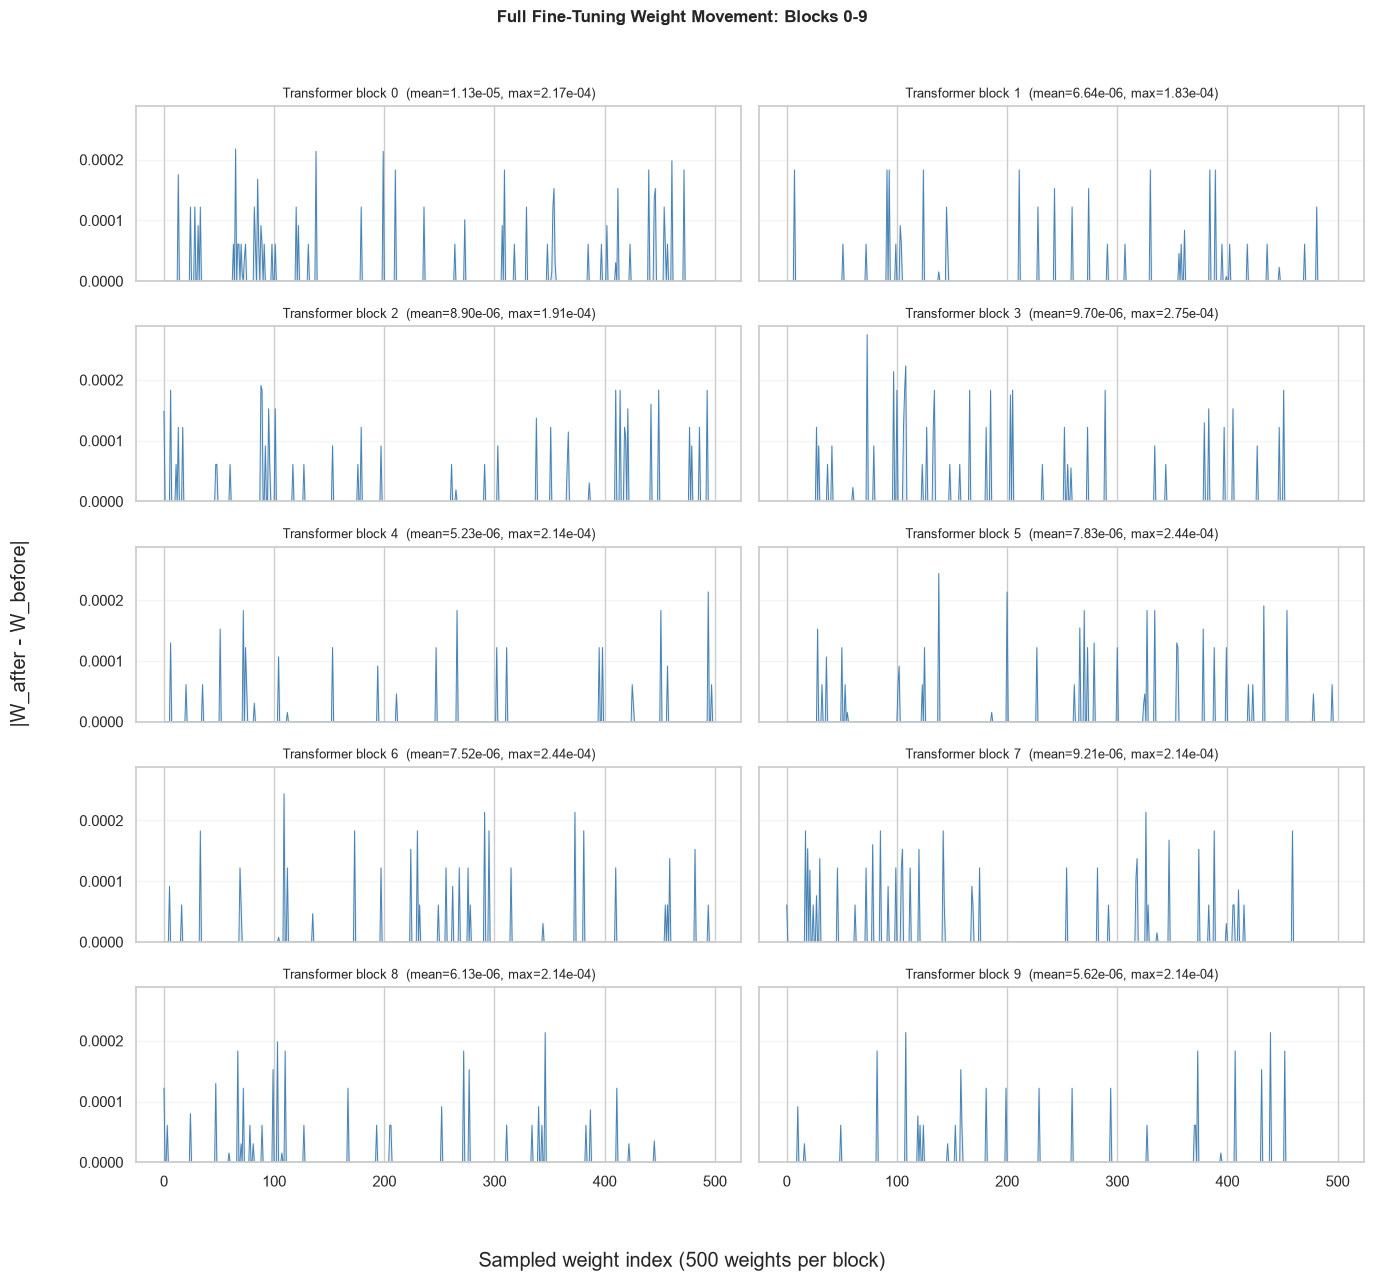

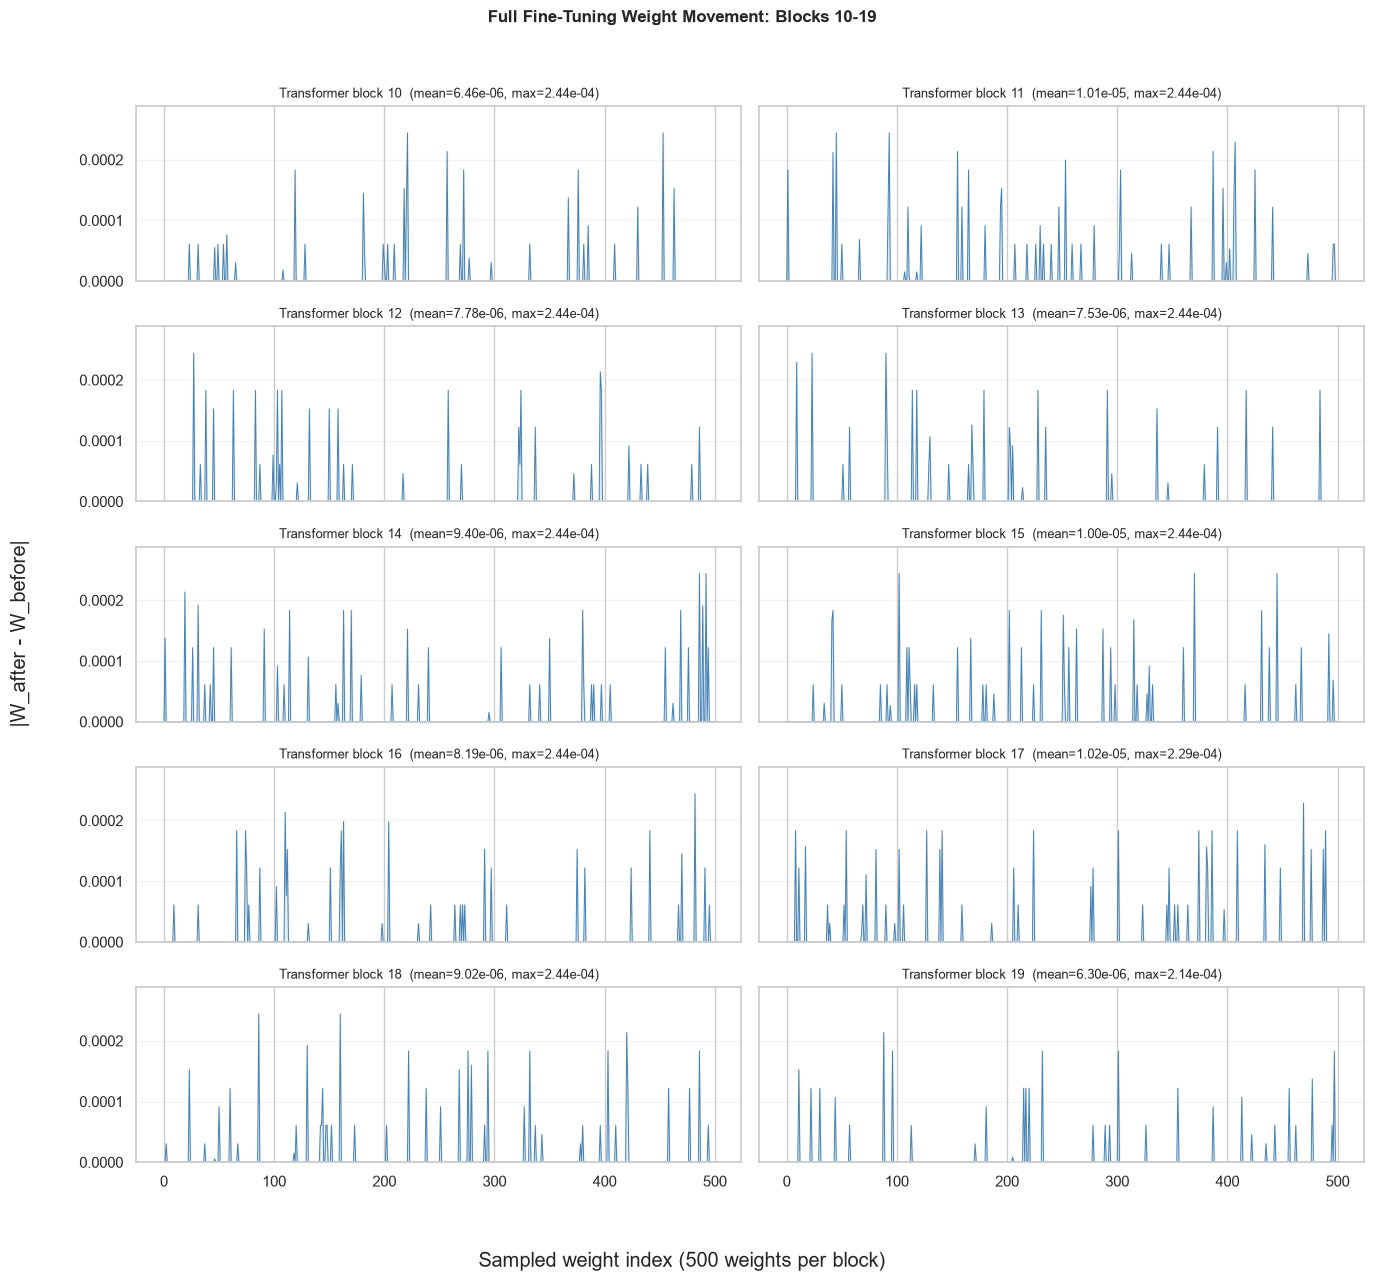

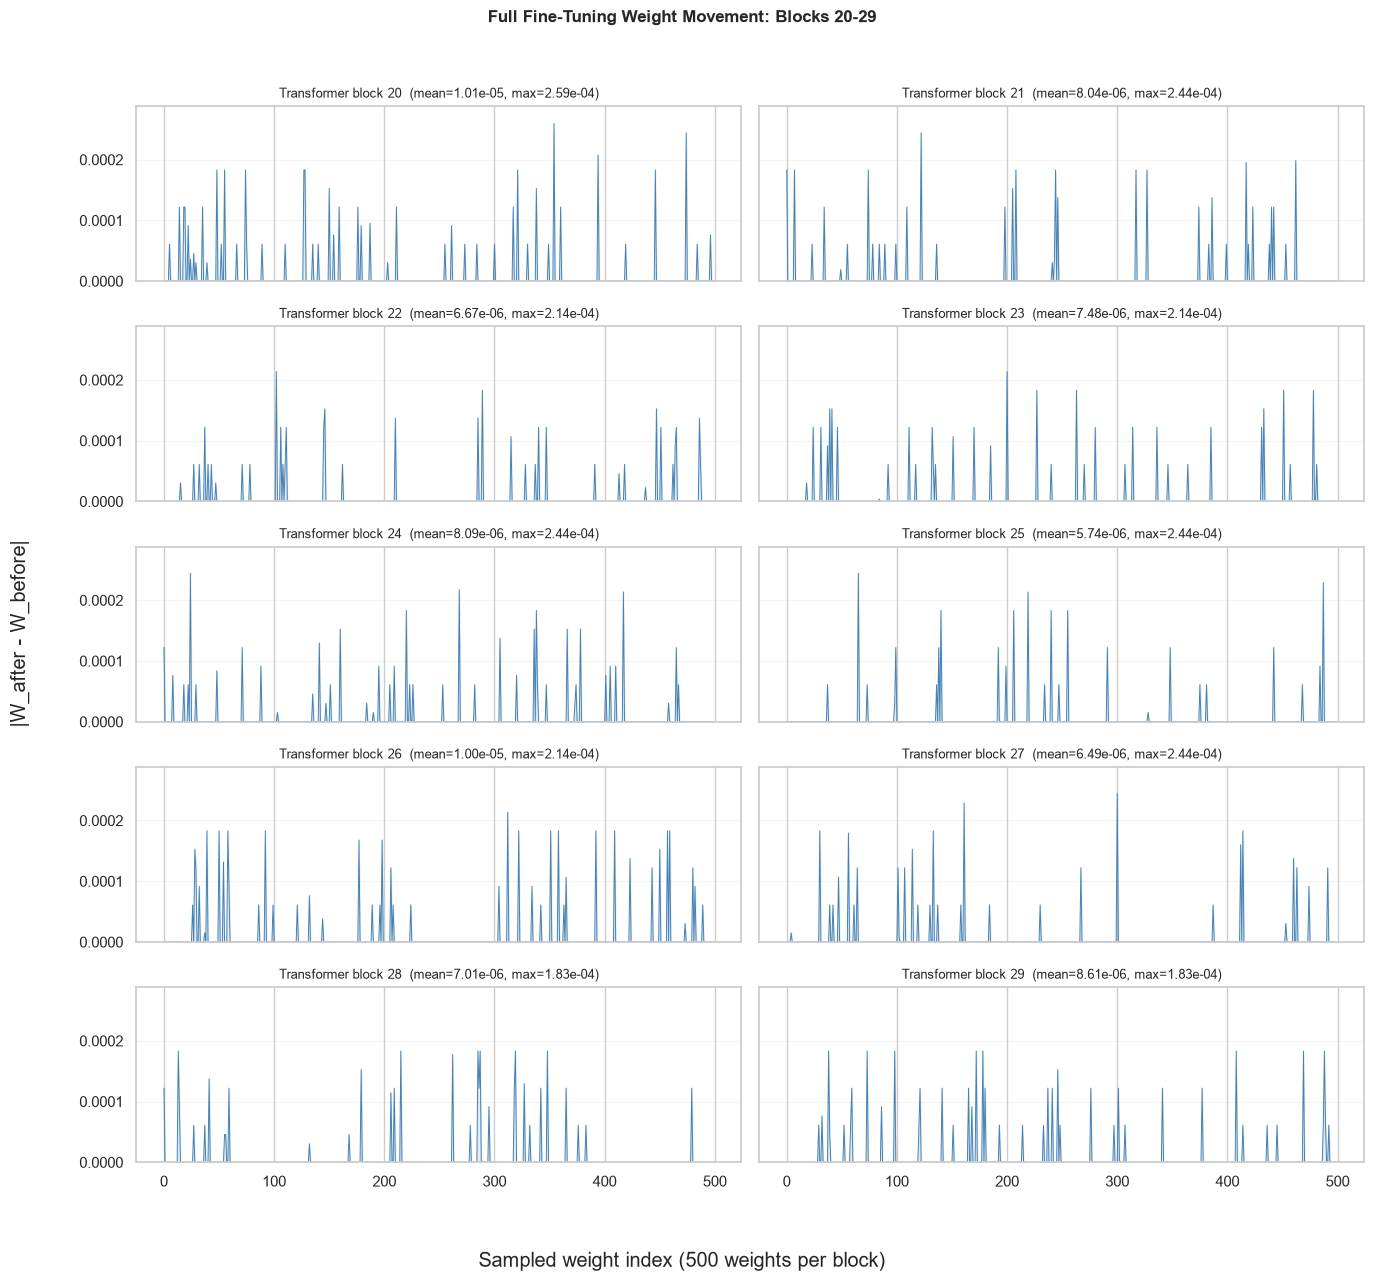

Mean |delta W| by block - min: block 4 (5.2338e-06), max: block 0 (1.1280e-05).
Freed the trace model; the checkpoint and manifest remain on disk.


In [90]:
# Reload the saved checkpoint and compare its real weight movement with the pinned CPT base.
import gc

base_state = dict(cpt_base_model.named_parameters())
ft_trace_model = AutoModelForCausalLM.from_pretrained(CPT_CHECKPOINT_DIR).to("cpu")

SAMPLES_PER_BLOCK = 500
PANELS_PER_FIGURE = 10
N_COLUMNS = 2

all_deltas = []
for block_index in range(len(cpt_base_model.model.layers)):
    block_deltas = []
    for name, parameter in ft_trace_model.named_parameters():
        if f"model.layers.{block_index}." in name:
            delta = (parameter.data.cpu() - base_state[name].data.cpu()).abs().flatten()
            block_deltas.append(delta)
    if block_deltas:
        combined = torch.cat(block_deltas)
        stride = max(1, len(combined) // SAMPLES_PER_BLOCK)
        all_deltas.append(combined[::stride][:SAMPLES_PER_BLOCK].float().numpy())

global_ymax = max(float(block.max()) for block in all_deltas)
y_limit = global_ymax * 1.05 if global_ymax > 0 else 1e-9

for page_start in range(0, len(all_deltas), PANELS_PER_FIGURE):
    page = all_deltas[page_start : page_start + PANELS_PER_FIGURE]
    row_count = (len(page) + N_COLUMNS - 1) // N_COLUMNS
    figure, axes = plt.subplots(
        row_count,
        N_COLUMNS,
        figsize=(14, 2.6 * row_count),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for panel_index, block_values in enumerate(page):
        block_index = page_start + panel_index
        weight_indices = np.arange(len(block_values))
        axis = axes[panel_index]
        axis.plot(weight_indices, block_values, linewidth=0.7, color="steelblue")
        axis.fill_between(weight_indices, block_values, alpha=0.12, color="steelblue")
        axis.set_title(
            f"Transformer block {block_index}  "
            f"(mean={block_values.mean():.2e}, max={block_values.max():.2e})",
            fontsize=9,
        )
        axis.set_ylim(0, y_limit)
        axis.grid(alpha=0.2, axis="y")

    for unused_axis in axes[len(page) :]:
        unused_axis.set_visible(False)

    page_end = page_start + len(page) - 1
    figure.suptitle(
        f"Full Fine-Tuning Weight Movement: Blocks {page_start}-{page_end}",
        fontsize=12,
        fontweight="bold",
    )
    figure.supxlabel(f"Sampled weight index ({SAMPLES_PER_BLOCK} weights per block)")
    figure.supylabel("|W_after - W_before|")
    plt.tight_layout(rect=(0.03, 0.03, 1, 0.96))
    plt.show()

peak_block = max(range(len(all_deltas)), key=lambda index: all_deltas[index].mean())
min_block = min(range(len(all_deltas)), key=lambda index: all_deltas[index].mean())
print(
    f"Mean |delta W| by block - min: block {min_block} "
    f"({all_deltas[min_block].mean():.4e}), max: block {peak_block} "
    f"({all_deltas[peak_block].mean():.4e})."
)

del ft_trace_model
gc.collect()
print("Freed the trace model; the checkpoint and manifest remain on disk.")

### Riverside Takeaway: What CPT Added

Return to the prediction:

- raw prose became next-token practice without inventing instructions;
- every real token contributed a target;
- long paragraph tails survived as overflow blocks; and
- full fine-tuning wrote changes across the network.

For Riverside, CPT is valuable when the repeated cost is **unfamiliar house prose**: names, relationships, terminology, and narrative patterns otherwise have to be supplied again and again. It does not solve the editor's interaction contract.

> **Next Riverside problem:** the model may continue the scene but ignore `exactly one sentence and stop`. That is why SFT exists.

## Concept 2: SFT - Turn Riverside's Editing Brief Into a Habit

### The Riverside Need

CPT lets the model rehearse manuscript prose, but Riverside editors still have to correct a different failure: the draft keeps going, restates the request, or ignores `exactly one sentence and stop`.

That repeated cleanup is not a vocabulary problem. It is a request/response problem. SFT teaches it with demonstrations that pair an editor request with the exact kind of answer Riverside wants.

### Make a Prediction

For one SFT example, predict the gradient boundary:

- the system and editor request must remain visible so the model knows what it is answering;
- those prompt tokens should receive no labels, because Riverside is not teaching the model to reproduce the request;
- only the assistant sentence and its EOS token should be supervised; and
- padding should remain ignored.

```text
[prompt: visible, labels=-100] [desired sentence: active labels + EOS] [padding: -100]
```

The exercise builds one real adjacent-paragraph demonstration, inspects its mask, scales the pattern across all 40 chapters, and trains a small LoRA adapter so the mechanism fits local hardware.

> **Bridge to preference learning:** SFT can demonstrate a valid response. It does not explain why one valid draft is more useful than another.

> **PyTorch → Keras:** `from peft import LoraConfig, get_peft_model, TaskType` — imports HuggingFace's PEFT library, which wraps a PyTorch model's targeted `nn.Linear` layers with low-rank adapter matrices and freezes everything else; the actual wrapping happens a few cells down. **Keras/TF equivalent:** there is no first-party `peft` support for `TFPreTrainedModel`s — the common Keras/TF pattern for parameter-efficient tuning is manual layer freezing (`layer.trainable = False` on all but the last few layers) rather than LoRA adapters, since PEFT's LoRA implementation is PyTorch-only.

In [ ]:
import gc
import re

from peft import LoraConfig, PeftModel, TaskType, get_peft_model

# CPT used two full model copies. Delete them before loading the SFT base model;
# otherwise a CPU machine keeps several hundred million unused weights in memory.
for model_name in (
    "trainer_full",
    "full_ft_model",
    "cpt_base_model",
    "base_model",
    "base_state",
):
    if model_name in globals():
        del globals()[model_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Freed continued-pretraining models before LoRA SFT.")

SYSTEM_PROMPT = "You are Riverside House's concise fiction-writing assistant."


def render_instruction(instruction, response=None):
    """Render one editor example with the model's native chat markers."""
    # Running shape before rendering:
    #   system: Riverside's assistant role
    #   user:   "Continue ... Context: <paragraph i>"
    #   assistant (training only): first sentence from paragraph i + 1
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": instruction.strip()},
    ]
    if response is None:
        # Generation stops at the assistant header so the model must supply the answer.
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

    # Training includes the desired assistant sentence and its native EOS marker.
    messages.append({"role": "assistant", "content": response.strip()})
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )


SFT_TRAIN_TASKS = (
    "Continue this Aria scene in exactly one sentence and stop.",
    "Write one sentence that continues this passage, then stop.",
)
INSTRUCTION_TASK = SFT_TRAIN_TASKS[0]


def first_complete_sentence(text, max_text_tokens=24):
    """Extract one complete sentence, shortening it to the response token budget."""
    # Example: paragraph i + 1 may contain four sentences. Keep only sentence one
    # because the editor contract asks for exactly one sentence and then a stop.
    text = text.strip()
    match = re.search(r"^.*?[.!?](?:[\"']?)(?=\s|$)", text)
    sentence = match.group(0).strip() if match else text
    words = sentence.split()

    # If sentence one is still too long, remove words from its end until the
    # tokenizer says it fits, then restore one terminal period.
    while words:
        candidate = " ".join(words).rstrip(" ,;:-.!?") + "."
        token_count = len(tokenizer(candidate, add_special_tokens=False)["input_ids"])
        if token_count <= max_text_tokens:
            return candidate
        words.pop()
    raise ValueError("Could not construct a complete bounded response sentence")


def load_sft_paragraphs(path, min_len=200):
    """Load the substantial prose paragraphs eligible for adjacent-pair synthesis."""
    return [
        paragraph.strip().replace("\n", " ")
        for paragraph in path.read_text(encoding="utf-8").split("\n\n")
        if len(paragraph.strip()) > min_len
    ]


def build_instruction_pairs(chapter_files, tasks, max_pairs=None):
    """Turn adjacent manuscript paragraphs into editor request/response examples."""
    pairs = []
    for path in chapter_files:
        # Step 1: keep substantial prose paragraphs and flatten internal line breaks.
        paragraphs = load_sft_paragraphs(path)

        # Step 2: slide across adjacent paragraphs. For (paragraph i, paragraph i+1),
        # paragraph i becomes context and paragraph i+1 supplies the desired answer.
        for pair_index, (context, next_paragraph) in enumerate(
            zip(paragraphs, paragraphs[1:])
        ):
            # Step 3: alternate equivalent requests so SFT teaches the response
            # contract rather than memorizing one exact command string.
            task = tasks[pair_index % len(tasks)]
            instruction = f"{task}\n\nContext:\n{context}"
            response = first_complete_sentence(next_paragraph)
            pairs.append({"instruction": instruction, "response": response})

            if max_pairs is not None and len(pairs) >= max_pairs:
                return pairs
    return pairs


# Sample adjacent pairs from the opening, middle, and final chapters. Selecting
# pair 1 in the middle chapter also demonstrates the alternate task template.
sample_chapter_indices = (0, len(ARIA_TRAIN_FILES) // 2, len(ARIA_TRAIN_FILES) - 1)
sample_pair_indices = (0, 1, 0)
SFT_SAMPLE_RECORDS = []
for sample_number, (chapter_index, pair_index) in enumerate(
    zip(sample_chapter_indices, sample_pair_indices),
    start=1,
):
    chapter_path = ARIA_TRAIN_FILES[chapter_index]
    source_paragraphs = load_sft_paragraphs(chapter_path)
    built_pair = build_instruction_pairs(
        [chapter_path],
        SFT_TRAIN_TASKS,
        max_pairs=pair_index + 1,
    )[pair_index]
    task, context = built_pair["instruction"].split("\n\nContext:\n", maxsplit=1)
    sample_record = {
        "chapter": chapter_path.name,
        "pair_index": pair_index,
        "context_paragraph": source_paragraphs[pair_index],
        "next_paragraph": source_paragraphs[pair_index + 1],
        "task": task,
        "instruction": built_pair["instruction"],
        "response": built_pair["response"],
    }
    SFT_SAMPLE_RECORDS.append(sample_record)

    print("\n" + "=" * 92)
    print(f"SFT SAMPLE {sample_number}: {chapter_path.name}, adjacent pair {pair_index}")
    print(f"Paragraph i (context source):\n{source_paragraphs[pair_index][:320]} ...")
    print(
        f"\nParagraph i + 1 (target source):\n"
        f"{source_paragraphs[pair_index + 1][:320]} ..."
    )
    print(f"\nSynthesized task:\n{task}")
    print(f"\nGenerated instruction context:\n{context[:320]} ...")
    print(f"\nExtracted response:\n{built_pair['response']}")

# Keep the opening sample as the running example for the token-budget walkthrough.
running_example = {
    "instruction": SFT_SAMPLE_RECORDS[0]["instruction"],
    "response": SFT_SAMPLE_RECORDS[0]["response"],
}
print("\nOne SFT data idea: harvest the manuscript's next sentence as an approved response.")
print("Then encode it as prompt-visible, response-only supervised chat data.")

### Inspect Sample Examples: Turn “What Happened Next” Into a Demonstration

Riverside already wrote thousands of useful continuations into the manuscript. The SFT data builder reuses that structure instead of asking an editor to author every example from scratch.

Here is the single governing idea:

```text
paragraph i
= the scene the model is given

first complete sentence from paragraph i + 1
= an example of a useful next response
```

The pipeline turns that implicit continuation into an explicit editor demonstration:

```text
manuscript before

paragraph i:
Aria studies the repeating signal.

paragraph i + 1:
She isolates the transmission and calls Wren. The bridge begins to respond.

                         ↓ harvest the existing continuation

SFT example after

Editor request:
Continue this scene in exactly one sentence and stop.

Context:
Aria studies the repeating signal.

Approved response:
She isolates the transmission and calls Wren.
```

Everything else serves this one transformation:

- alternate two equivalent request wordings so the lesson is not tied to one exact command;
- keep as much context and response text as the token budget allows;
- serialize the result with SmolLM2’s native chat roles and EOS marker; and
- show the prompt to the model while applying loss only to the approved response.

So the pipeline has two conceptual stages, not seven separate techniques:

```text
1. Harvest an editor demonstration from adjacent prose.
2. Encode that demonstration so only the assistant answer is supervised.
```

The next code cell samples the opening, middle, and final chapter and runs each through the same `build_instruction_pairs()` function used for the full dataset.

**Your prediction:** after encoding one pair, the task and bounded context should occupy at most 64 prompt tokens, the assistant suffix should occupy at most 32 tokens including one EOS, and only assistant positions should carry active labels.

### Tokenizing With the Prompt-Mask Pattern

Token-aware budgeting keeps at most 64 native prompt tokens and at most 32 native assistant-suffix tokens inside 96 positions. Prompt and padding labels are `-100`, and exactly one assistant EOS token is supervised.


> **PyTorch → Keras:** `tokenize_instruction()` — builds `labels` as a copy of the tokenized `input_ids`, then overwrites *both* the prompt-token positions and the padding positions with `-100`, so a cross-entropy loss with `ignore_index=-100` (used earlier in the notebook) only ever grades the completion tokens. **Keras/TF equivalent:** the same masking logic — a Keras/TF version would build an analogous `labels` array with `-100` (or `0` plus a matching `sample_weight` mask, since TF's `SparseCategoricalCrossentropy` has no built-in `ignore_index`) at prompt+padding positions; the tokenization itself is identical since `AutoTokenizer` is framework-agnostic.

In [92]:
_SFT_CONTEXT_MARKER = "\n\nContext:\n"


def _sft_token_ids(text):
    """Tokenize rendered text without injecting another BOS or EOS token."""
    # Example: when `text` is the rendered opening Aria prompt, these are the
    # exact IDs whose length must fit inside the 64-token prompt budget.
    return tokenizer(text, add_special_tokens=False)["input_ids"]


def _sft_prefix_encoding(text):
    """Tokenize source prose and retain character offsets when supported."""
    # For the opening sample, offsets map every context token back to the exact
    # substring in "Aria Voss had learned to listen to the ship ...".
    if tokenizer.is_fast:
        return tokenizer(text, add_special_tokens=False, return_offsets_mapping=True)
    return tokenizer(text, add_special_tokens=False)


def _sft_token_prefix_text(text, encoding, token_count):
    """Recover the source-text prefix covered by the first `token_count` tokens."""
    if token_count == 0:
        return ""

    # Fast tokenizers expose exact character boundaries. This avoids decoding a
    # token prefix into subtly different whitespace before chat serialization.
    offsets = encoding.get("offset_mapping")
    if offsets is not None:
        return text[: offsets[token_count - 1][1]].rstrip()

    # Slow-tokenizer fallback: decode the prefix as faithfully as possible.
    return tokenizer.decode(
        encoding["input_ids"][:token_count],
        skip_special_tokens=False,
        clean_up_tokenization_spaces=False,
    ).rstrip()


def _sft_largest_fitting_prefix(text, max_source_tokens, build_candidate):
    """Use binary search to find the longest source prefix accepted by a builder."""
    encoding = _sft_prefix_encoding(text)
    low = 0
    high = min(len(encoding["input_ids"]), max_source_tokens)
    best = None

    # Running example: try a context prefix near the middle of the search range,
    # render it with the system/task chat overhead, then keep the longer half if
    # the rendered prompt fits. This takes O(log n) renderings instead of trying
    # every possible prefix from 0 through 64 tokens.
    while low <= high:
        token_count = (low + high) // 2
        prefix = _sft_token_prefix_text(text, encoding, token_count)
        candidate = build_candidate(prefix)
        if candidate is None:
            high = token_count - 1
        else:
            best = candidate
            low = token_count + 1

    return best


def _sft_bounded_prompt(instruction, prompt_max_length):
    """Keep the task and as much context as fits in the rendered prompt budget."""
    # Example input shape:
    #   "Continue ... stop.\n\nContext:\nAria Voss had learned ..."
    task, marker, context = instruction.strip().partition(_SFT_CONTEXT_MARKER)
    if not marker:
        raise ValueError("Instruction is missing the expected Context section")

    context = context.strip()
    instruction_prefix = task + marker

    def build_candidate(bounded_context):
        # The fixed system message, role markers, task, and context all consume
        # prompt tokens. Therefore we test the fully rendered prompt, not the
        # context token count by itself.
        bounded_instruction = instruction_prefix + bounded_context
        prompt_text = render_instruction(bounded_instruction)
        prompt_ids = _sft_token_ids(prompt_text)
        if len(prompt_ids) <= prompt_max_length:
            return bounded_instruction, prompt_text, prompt_ids
        return None

    result = _sft_largest_fitting_prefix(
        context, prompt_max_length, build_candidate
    )
    if result is None:
        raise ValueError("The fixed instruction template exceeds the prompt budget")
    return result


def _sft_bounded_assistant_suffix(
    bounded_instruction,
    prompt_text,
    prompt_ids,
    response,
    assistant_max_length,
):
    """Build the longest stable assistant suffix that ends in exactly one EOS."""
    if tokenizer.eos_token is None or tokenizer.eos_token_id is None:
        raise ValueError("The tokenizer must define an EOS token")

    def build_candidate(bounded_response):
        # Running example: append "It came through her handset ..." as the
        # assistant turn, then let SmolLM2's chat template add its EOS marker.
        full_text = render_instruction(bounded_instruction, bounded_response)
        assert full_text.startswith(prompt_text), (
            "Native chat template did not preserve the exact prompt text prefix"
        )

        # Keep the assistant text only through its final EOS. Anything a template
        # might place afterward is outside the supervised response suffix.
        assistant_text = full_text[len(prompt_text) :]
        eos_offset = assistant_text.rfind(tokenizer.eos_token)
        if eos_offset < 0:
            raise ValueError("Native assistant rendering did not contain EOS")

        through_eos_text = prompt_text + assistant_text[
            : eos_offset + len(tokenizer.eos_token)
        ]
        through_eos_ids = _sft_token_ids(through_eos_text)

        # Token boundaries can change where prompt and response meet. Accept the
        # candidate only if re-tokenizing the combined text preserves every prompt ID.
        if through_eos_ids[: len(prompt_ids)] != prompt_ids:
            return None

        assistant_ids = through_eos_ids[len(prompt_ids) :]
        if (
            len(assistant_ids) <= assistant_max_length
            and assistant_ids
            and assistant_ids[-1] == tokenizer.eos_token_id
            and assistant_ids.count(tokenizer.eos_token_id) == 1
        ):
            return assistant_ids
        return None

    result = _sft_largest_fitting_prefix(
        response.strip(), assistant_max_length, build_candidate
    )
    if result is None:
        raise ValueError("No stable native assistant suffix fits the assistant budget")
    return result


def tokenize_instruction(
    example,
    max_length=96,
    prompt_max_length=64,
    assistant_max_length=32,
):
    """Encode one SFT pair as prompt-masked causal-language-model tensors."""
    if prompt_max_length + assistant_max_length != max_length:
        raise ValueError("Prompt and assistant budgets must sum to max_length")
    if tokenizer.pad_token_id is None:
        raise ValueError("The tokenizer must define a padding token")

    # Stage 1: preserve the task and bound the Aria context inside 64 tokens.
    bounded_instruction, prompt_text, prompt_ids = _sft_bounded_prompt(
        example["instruction"], prompt_max_length
    )

    # Stage 2: serialize a bounded assistant response plus exactly one EOS.
    assistant_ids = _sft_bounded_assistant_suffix(
        bounded_instruction,
        prompt_text,
        prompt_ids,
        example["response"],
        assistant_max_length,
    )

    # Stage 3: concatenate prompt and response, then right-pad to 96 positions.
    # All active tokens keep attention_mask=1: the response must be able to read the prompt.
    active_ids = prompt_ids + assistant_ids
    padding_length = max_length - len(active_ids)
    if padding_length < 0:
        raise AssertionError("Bounded prompt and assistant suffix exceed max_length")

    input_ids = active_ids + [tokenizer.pad_token_id] * padding_length
    attention_mask = [1] * len(active_ids) + [0] * padding_length

    # Stage 4 controls loss, not visibility. Prompt tokens stay visible through attention,
    # but labels=-100 prevents the model from being graded on reproducing them.
    # Only assistant IDs, including EOS, remain active next-token targets.
    labels = [-100] * len(prompt_ids) + assistant_ids + [-100] * padding_length

    assert assistant_ids[-1] == tokenizer.eos_token_id
    assert assistant_ids.count(tokenizer.eos_token_id) == 1
    assert len(input_ids) == len(attention_mask) == len(labels) == max_length
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


# Trace the opening Aria sample through the exact helpers used for every row.
trace_task, _, trace_original_context = running_example["instruction"].partition(
    _SFT_CONTEXT_MARKER
)
trace_bounded_instruction, trace_prompt_text, trace_prompt_ids = _sft_bounded_prompt(
    running_example["instruction"],
    prompt_max_length=64,
)
_, _, trace_bounded_context = trace_bounded_instruction.partition(_SFT_CONTEXT_MARKER)
trace_assistant_ids = _sft_bounded_assistant_suffix(
    trace_bounded_instruction,
    trace_prompt_text,
    trace_prompt_ids,
    running_example["response"],
    assistant_max_length=32,
)
trace_encoded = tokenize_instruction(running_example)
trace_active_length = sum(trace_encoded["attention_mask"])
trace_padding_length = len(trace_encoded["input_ids"]) - trace_active_length
trace_assistant_text = tokenizer.decode(
    trace_assistant_ids[:-1],
    skip_special_tokens=False,
).strip()

print("\n=== RUNNING TOKEN-BUDGET EXAMPLE: CHAPTER 1 ===")
print(f"Task preserved: {trace_task}")
print(
    f"Context: {len(_sft_token_ids(trace_original_context))} source tokens "
    f"-> {len(_sft_token_ids(trace_bounded_context))} retained context tokens"
)
print(f"Bounded context tail: ...{trace_bounded_context[-140:]}")
print(f"Rendered prompt: {len(trace_prompt_ids)} / 64 tokens")
print(f"Assistant text: {trace_assistant_text!r}")
print(f"Assistant suffix: {len(trace_assistant_ids)} / 32 tokens, including one EOS")
print(
    f"Final 96 positions: {len(trace_prompt_ids)} masked prompt + "
    f"{len(trace_assistant_ids)} active assistant + {trace_padding_length} masked padding"
)
print(
    "Label pattern: "
    f"[-100 x {len(trace_prompt_ids)}] + [assistant IDs x {len(trace_assistant_ids)}] + "
    f"[-100 x {trace_padding_length}]"
)


=== RUNNING TOKEN-BUDGET EXAMPLE: CHAPTER 1 ===
Task preserved: Continue this Aria scene in exactly one sentence and stop.
Context: 182 source tokens -> 22 retained context tokens
Bounded context tail: ...Aria Voss had learned to listen to the ship the way other people listened to weather. Two hundred and
Rendered prompt: 64 / 64 tokens
Assistant text: 'It came through her handset at 0340 ship-time, filtered up out of the ancient.'
Assistant suffix: 24 / 32 tokens, including one EOS
Final 96 positions: 64 masked prompt + 24 active assistant + 8 masked padding
Label pattern: [-100 x 64] + [assistant IDs x 24] + [-100 x 8]


### Exercise 1 - Build and Inspect the Contract

**Riverside problem:** manuscript adjacency contains the desired next sentence, but not the chat-shaped demonstration the assistant needs.

**Prediction:** the first encoded row should spend at most 64 positions on the request, at most 32 on the response, supervise exactly one EOS token, and mask every prompt and padding position.

**Run:** build demonstrations from all chapters, inspect the first request/response pair, then assert the same contract across the full dataset.

In [107]:
instruction_pairs = build_instruction_pairs(ARIA_TRAIN_FILES, SFT_TRAIN_TASKS)
instruction_dataset = Dataset.from_list(instruction_pairs)
instruction_tokenized = instruction_dataset.map(
    tokenize_instruction,
    remove_columns=["instruction", "response"],
)

for row in instruction_tokenized:
    input_ids = row["input_ids"]
    attention_mask = row["attention_mask"]
    labels = row["labels"]
    assert len(input_ids) == len(attention_mask) == len(labels) == 96
    prompt_boundary = next(index for index, label in enumerate(labels) if label != -100)
    active_length = sum(attention_mask)
    active_response_labels = labels[prompt_boundary:active_length]
    decoded_response = tokenizer.decode(
        active_response_labels[:-1],
        skip_special_tokens=False,
    ).strip()
    # Region 1 - prompt: visible to attention, excluded from loss.
    assert all(label == -100 for label in labels[:prompt_boundary])
    assert all(attention_mask[index] == 1 for index in range(prompt_boundary))

    # Region 2 - assistant: visible and supervised, ending in exactly one EOS.
    assert all(label != -100 for label in active_response_labels)
    assert all(attention_mask[index] == 1 for index in range(prompt_boundary, active_length))

    # Region 3 - padding: invisible to attention and excluded from loss.
    assert all(label == -100 for label in labels[active_length:])
    assert all(mask == 0 for mask in attention_mask[active_length:])
    assert prompt_boundary <= 64
    assert len(active_response_labels) <= 32
    assert active_response_labels.count(tokenizer.eos_token_id) == 1
    assert active_response_labels[-1] == tokenizer.eos_token_id
    assert decoded_response.endswith(".")

example_instruction = instruction_pairs[0]
example_encoded = instruction_tokenized[0]
example_prompt_tokens = next(
    index for index, label in enumerate(example_encoded["labels"]) if label != -100
)
example_active_tokens = sum(example_encoded["attention_mask"])
example_response_tokens = example_active_tokens - example_prompt_tokens

print("INSPECT ONE SFT DEMONSTRATION")
print(f"Editor request: {example_instruction['instruction'][:260]!r}")
print(f"Desired response: {example_instruction['response']!r}")
print(f"Masked prompt tokens: {example_prompt_tokens}")
print(f"Supervised response tokens: {example_response_tokens}")
print("Supervised EOS tokens: 1")
print(f"\nScaled to {len(instruction_pairs):,} demonstrations from all 40 chapters.")

Map: 100%|██████████| 724/724 [00:02<00:00, 247.66 examples/s]


INSPECT ONE SFT DEMONSTRATION
Editor request: "Continue this Aria scene in exactly one sentence and stop.\n\nContext:\nAria Voss had learned to listen to the ship the way other people listened to weather. Two hundred and fourteen years after the Meridian's Promise had folded its sails of solar canvas and slip"
Desired response: 'It came through her handset at 0340 ship-time, filtered up out of the ancient.'
Masked prompt tokens: 64
Supervised response tokens: 24
Supervised EOS tokens: 1

Scaled to 724 demonstrations from all 40 chapters.


### A Quick LoRA Preview for This SFT Run

SFT defines **what behavior is taught**. LoRA only changes **where the update is stored**: `get_peft_model()` freezes the base and adds small trainable correction matrices to selected attention projections.

That is enough detail for this chapter. The next code cell uses LoRA so the SFT run fits local hardware; Part 2 derives the low-rank path, measures its parameter budget, and inspects the real matrices.

> **PyTorch → Keras:** `LoraConfig(...)` and `get_peft_model(...)` target the four SmolLM2 attention
projections (`q_proj`, `k_proj`, `v_proj`, `o_proj`) and report the resulting trainable fraction.
PEFT's wrapping is PyTorch-specific; a Keras implementation needs a compatible low-rank layer wrapper or
manual custom layers rather than coarse whole-layer freezing.


In [94]:
# Rank-8 adapters on all four attention projections.
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=0.05,
    bias="none",
)

instruct_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
).to(device)

# Keep two fixed requests for a fair before/after display. These are drawn from
# the training examples, so they demonstrate the mechanism rather than generalization.
sft_demo_indices = (0, len(instruction_pairs) // 2)
SFT_DEMO_CASES = [instruction_pairs[index] for index in sft_demo_indices]
SFT_DEMO_PROMPTS = [
    _sft_bounded_prompt(example["instruction"], prompt_max_length=64)[1]
    for example in SFT_DEMO_CASES
]
SFT_BEFORE_OUTPUTS = [
    generate(
        instruct_base,
        prompt,
        tokenizer,
        max_new_tokens=40,
        seed=EXPERIMENT_SEED + case_number,
    )
    for case_number, prompt in enumerate(SFT_DEMO_PROMPTS, start=1)
]

# get_peft_model() freezes the base weights and inserts trainable LoRA matrices.
instruct_lora_model = get_peft_model(instruct_base, lora_config)
instruct_lora_model.print_trainable_parameters()

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 2445.33it/s]


trainable params: 921,600 || all params: 135,436,608 || trainable%: 0.6805


### Training and Saving the Adapter

> **SFT teaching run:** batch size `1`, learning rate `2e-4`, and `10` optimizer steps. The rank-8 LoRA adapter targets `q_proj`, `k_proj`, `v_proj`, and `o_proj`, uses alpha `16`, and applies adapter dropout `0.05`. Only the adapter matrices move, so this run can use a larger learning rate than the full-model CPT demonstration.

The objective-specific controls are the prompt/response token budgets, response-only label mask, and supervised EOS. Part 2 owns the deeper explanation of LoRA rank, alpha, dropout, and target modules; the bottom **[Tunable Parameters]** section connects them to the shared optimizer controls.

> **PyTorch → Keras:** `Trainer(model=instruct_lora_model, ...)` / `trainer_instruct.train()` / `instruct_lora_model.save_pretrained(...)` — the same HuggingFace `Trainer` pattern as the earlier full fine-tuning run, just pointed at the LoRA-wrapped model and the prompt-masked instruction dataset, with a higher learning rate since only the small adapter matrices are being updated. **Keras/TF equivalent:** `model.fit(dataset, epochs=...)` — as with the earlier full fine-tuning cell, a Keras/TF version would call `.fit()` on the (layer-frozen) model instead of `Trainer.train()`; `save_pretrained()` again has an identically-named counterpart on `TFPreTrainedModel`.

In [95]:
# Short LoRA run to expose response-masked SFT and adapter saving.
training_args_instruct = TrainingArguments(
    output_dir=str(SFT_CHECKPOINT_DIR),
    per_device_train_batch_size=1,
    max_steps=DEMO_TRAIN_STEPS,
    logging_steps=1,
    save_strategy="no",
    learning_rate=2e-4,
    seed=EXPERIMENT_SEED,
    data_seed=EXPERIMENT_SEED,
    report_to="none",
)

trainer_instruct = Trainer(
    model=instruct_lora_model,
    args=training_args_instruct,
    train_dataset=instruction_tokenized,
)
trainer_instruct.train()
instruct_lora_model.save_pretrained(SFT_CHECKPOINT_DIR)
tokenizer.save_pretrained(SFT_CHECKPOINT_DIR)
write_artifact_manifest(
    stage="supervised-fine-tuning-lora",
    output_dir=SFT_CHECKPOINT_DIR,
    training_files=ARIA_TRAIN_FILES,
    training_args=training_args_instruct,
    extra={
        "objective": "response-masked causal language modeling",
        "parameter_strategy": "lora",
        "training_tasks": list(SFT_TRAIN_TASKS),
    },
)
print("Saved SFT LoRA adapter and training-provenance manifest.")

SFT_AFTER_OUTPUTS = [
    generate(
        instruct_lora_model,
        prompt,
        tokenizer,
        max_new_tokens=40,
        seed=EXPERIMENT_SEED + case_number,
    )
    for case_number, prompt in enumerate(SFT_DEMO_PROMPTS, start=1)
]

print("\n=== SFT before/after: in-sample mechanism probes ===")
for case_number, (example, before_sft, after_sft) in enumerate(
    zip(SFT_DEMO_CASES, SFT_BEFORE_OUTPUTS, SFT_AFTER_OUTPUTS),
    start=1,
):
    task, context = example["instruction"].split("\n\nContext:\n", maxsplit=1)
    print(f"\nCase {case_number}")
    print(f"Request:    {task}")
    print(f"Context:    {context[:180]} ...")
    print(f"Target:     {example['response']}")
    print(f"Before SFT: {before_sft}")
    print(f"After SFT:  {after_sft}")

Step,Training Loss
1,4.328879
2,3.621421
3,3.314097
4,4.618239
5,4.592667
6,4.075068
7,8.110389
8,3.842007
9,3.930670
10,4.422467


Wrote provenance manifest: c:\r\ai-portfolio\checkpoints\llm-finetuning\cpu-small-135m\instruction-lora\experiment-manifest.json
Saved SFT LoRA adapter and training-provenance manifest.

=== SFT before/after: in-sample mechanism probes ===

Case 1
Request:    Continue this Aria scene in exactly one sentence and stop.
Context:    Aria Voss had learned to listen to the ship the way other people listened to weather. Two hundred and fourteen years after the Meridian's Promise had folded its sails of solar canv ...
Target:     It came through her handset at 0340 ship-time, filtered up out of the ancient.
Before SFT: Aria's eyes, wide with wonder, stared out the window as the bright blue light of the morning sky filtered through the fog. She had learned to listen to the way people listened to the
After SFT:  Aria's eyes, wide with wonder, stared out the window as the bright blue light of the sun cast a golden glow across the calm waters. The ship, the Luminari, had

Case 2
Request:    Write 

### Riverside Takeaway: What SFT Added

Return to the prediction:

- the editor request stayed visible but contributed no labels;
- the desired assistant sentence and one EOS token carried the gradient;
- the same contract scaled across the complete corpus; and
- a small LoRA adapter stored the workflow-specific update.

For Riverside, SFT is valuable when editors repeatedly correct **how the assistant responds**: format, scope, role, and stopping behavior. It can reduce boilerplate and cleanup across many requests.

> **Next Riverside problem:** two drafts can both obey the contract while one merely repeats the setup. Riverside still needs a way to express editorial taste.

### The Instruction-Tuning Mask Layout, For Real

Contrast this with the continued-pretraining mask layout earlier in the notebook: there, only **padding** was masked, and every real token was active. Here, the **bounded prompt context is masked**, while the **bounded assistant suffix is supervised**. The model is penalized only for the assistant suffix, including exactly one EOS token, never for reproducing the prompt it was given. The cell below takes one real `(prompt, completion)` pair from `instruction_pairs`, runs it through the real `tokenize_instruction()` used for training, and colors every token position by what the label mask actually does with it.


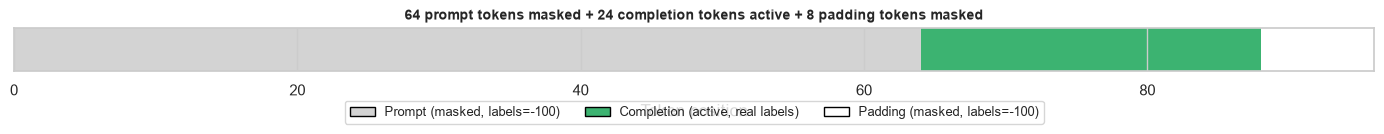

Prompt text:     "<|im_start|>system\nYou are Riverside House's concise fiction-writing assistant.<"...
Completion text: 'It came through her handset at 0340 ship-time, filtered up out of the ancient.'...

Masked (prompt): 64 tokens | Active (completion): 24 tokens | Masked (padding): 8 tokens
Compare to continued pretraining: there, every real token was active. Here, the prompt is masked too, so the model only ever gets gradient signal from the completion.


In [96]:
# Real mask layout for instruction tuning: prompt masked (-100), completion active, padding masked
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

example_pair = instruction_pairs[0]
encoded_example = tokenize_instruction(example_pair)
example_labels = np.array(encoded_example["labels"])
example_attention = np.array(encoded_example["attention_mask"])

# Classify every position: 0 = masked prompt, 1 = active completion, 2 = masked padding
region = np.zeros(len(example_labels), dtype=int)
region[example_attention == 0] = 2  # padding
region[(example_attention == 1) & (example_labels != -100)] = 1  # completion (active)

# everything else (attention==1 & labels==-100) is the masked prompt, stays 0

prompt_masked = int(np.sum(region == 0))
completion_active = int(np.sum(region == 1))
padding_masked = int(np.sum(region == 2))

# Visualize the mask layout as a single color-coded strip (gray=prompt, green=completion, white=padding)
fig, ax = plt.subplots(figsize=(14, 2.2))
cmap = ListedColormap(["lightgray", "mediumseagreen", "white"])
ax.imshow(
    region.reshape(1, -1),
    cmap=cmap,
    aspect="auto",
    vmin=0,
    vmax=2,
    extent=[0, len(region), 0, 1],
)
ax.set_yticks([])
ax.set_xlabel("Token position")
ax.set_title(
    f"{prompt_masked} prompt tokens masked + {completion_active} completion tokens active "
    f"+ {padding_masked} padding tokens masked",
    fontsize=10,
    fontweight="bold",
)

# Legend entries matching each color band in the strip above
legend_handles = [
    Patch(
        facecolor="lightgray", edgecolor="black", label="Prompt (masked, labels=-100)"
    ),
    Patch(
        facecolor="mediumseagreen",
        edgecolor="black",
        label="Completion (active, real labels)",
    ),
    Patch(facecolor="white", edgecolor="black", label="Padding (masked, labels=-100)"),
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.55),
    ncol=3,
    fontsize=9,
)

plt.tight_layout()
plt.show()

print(f"Prompt text:     {render_instruction(example_pair['instruction'])[:80]!r}...")
print(f"Completion text: {example_pair['response'][:80]!r}...")
print(
    f"\nMasked (prompt): {prompt_masked} tokens | Active (completion): {completion_active} tokens "
    f"| Masked (padding): {padding_masked} tokens"
)
print(
    "Compare to continued pretraining: there, every real token was active. Here, the prompt is "
    "masked too, so the model only ever gets gradient signal from the completion."
)

## Concept 3: Preference Learning - Teach the Choice Editors Keep Making

### The Riverside Need

SFT can produce two perfectly valid one-sentence drafts:

```text
Context: Aria watched the prime-number signal repeat across node seventeen.

Draft A: Aria isolated the transmission and called Wren to verify that the pattern was artificial.
Draft B: Aria considered the signal again and remained where she was while nothing changed.
```

Both stop correctly. Only Draft A earns its place in the manuscript. If editors repeatedly make that distinction, Riverside has information that a plain demonstration hides: **relative preference**.

### Make a Prediction

A useful preference example should keep everything except the editorial distinction controlled: one shared prompt, one chosen response, one rejected response, and comparable response lengths so the model cannot learn a length shortcut.

An SFT example says, `practice this response`. A preference pair says, `for this request, prefer this response to that response`.

The next choice is operational: does Riverside need fresh feedback from a changing environment, or does it already have a fixed archive of editorial comparisons?

### PPO: Learn a Judge, Then Learn From Fresh Experience

PPO joins **two different training loops**:

1. Train a judge from editor comparisons, then freeze it.
2. Let the writer produce fresh drafts and learn cautiously from the judge's scores.

#### First Train the Judge

Riverside starts with comparisons:

```text
Chosen:  Aria isolates the transmission and calls Wren.
Rejected: Aria considers the signal again but changes nothing.
```

At first, the judge scores the two drafts too similarly:

```text
chosen score   0.40
rejected score 0.20
score gap      0.20  -> weak confidence in the editor's choice
```

Training increases the chosen-minus-rejected gap. The penalty used to teach that ordering is called the **reward-model loss**. Once the judge reliably reproduces qualified editor preferences, Riverside freezes it. During the writer-training loop, the judge supplies scores but receives no updates.

The judge does not discover quality by itself. Human comparisons, verified tool outcomes, simulator results, or an explicit rubric define what its scores mean. A proxy judge still needs calibration against qualified human decisions.

#### Why PPO Needs Two Frozen Baselines

The two baselines do not do the same job. They answer different questions on different timescales:

1. **Accepted SFT reference:** "Has the writer drifted too far from the trusted assistant we started with?"
2. **Old policy for this batch:** "Has this update moved too far from the writer that generated these rollouts?"

The first baseline is copied once and kept for the entire preference-optimization run. The second is refreshed for every rollout batch. Both remain frozen while that batch is being optimized, but only the SFT reference survives unchanged into the next batch.

| Baseline | When it is captured | How long it stays fixed | What the current writer is compared against | Why PPO needs it |
| --- | --- | --- | --- | --- |
| Accepted SFT reference | Once, before preference optimization begins | The whole run | The original trusted SFT behavior | Charge for cumulative drift from the response contract |
| Old policy | When the current writer generates a rollout batch | Only while that batch is updated | The exact policy that produced those sampled tokens | Detect and clip an excessive one-batch probability change |

Follow one batch:

```text
start of preference training
    accepted SFT model -> frozen SFT reference
    accepted SFT model -> trainable current writer

batch 1
    current writer generates rollouts
    save its token probabilities as the old policy
    update current writer
      compare with SFT reference -> long-run drift penalty
      compare with old policy    -> one-batch ratio and clipping

batch 2
    updated writer generates new rollouts
    refresh the old-policy probabilities
    keep the same SFT reference
```

So the old policy is a short-lived **before-photo of one batch**, while the SFT reference is the permanent **starting-point photo of the whole run**. Implementations may cache the old token log-probabilities instead of storing a second full model; conceptually, they serve the same old-policy comparison.

#### Discover the PPO Terms by Following One Rollout

##### 1. The Writer Tries Something New

The current policy receives a Riverside prompt and samples a fresh draft. Sampling matters: PPO learns from experience produced by the changing writer, not only from a fixed archive.

```text
Prompt: Continue the Aria scene in one sentence.
Draft:  Aria isolates the signal, routes it into a sandbox, and calls Wren.
```

##### 2. The Frozen Judge Scores the Result

Suppose the judge assigns the complete draft:

```text
judge score = 0.80
```

This outcome score is the **reward**. Higher reward says the completed draft better matches the learned editorial preference. Reward supplies the direction of improvement, but optimizing it alone is dangerous: the writer could exploit quirks in the judge and abandon useful SFT behavior.

##### 3. Charge the Writer for Leaving Trusted Behavior

Compare the sampled draft under the current writer and the accepted SFT reference. Suppose the sampled divergence produces a cost of `0.15`.

```text
reward                         +0.80  encourage editorial usefulness
SFT-reference drift cost       -0.15  discourage abandoning trusted behavior
                               -----
regularized return              0.65
```

The drift charge is commonly called a **reference penalty** or **KL penalty**. It is subtracted because PPO should improve the reward while paying a price for moving away from the accepted response contract.

The resulting `0.65` is the **regularized return**: what the rollout was worth after accounting for both desired improvement and behavioral drift.

##### 4. Ask How Well the Writer Did for This Context

A raw outcome does not say whether the writer did unusually well. The same score can be impressive for a difficult context and routine for an easy one. PPO needs a context-sensitive expectation before it can assign fair credit.

That is the value model's job. As the response unfolds, it reads the prompt and the partial draft and predicts the regularized return a typical completion should achieve from that point. It is an **expectation setter**, not a second editorial judge.

| Model | Question it answers | What happens during PPO |
| --- | --- | --- |
| Reward model, or judge | How good was the completed draft? | It stays frozen and scores the outcome |
| Value model, or critic | Given this context and the draft so far, how well should the writer normally do? | It learns to make more accurate expectations |

Suppose two rollouts both finish with a regularized return of `0.60`:

| Context | Value model's expected return | Actual return | What PPO learns |
| --- | ---: | ---: | --- |
| Difficult prompt with an uncertain partial draft | `0.30` | `0.60` | Much better than expected: give this path strong positive credit |
| Easy prompt with an already-promising partial draft | `0.55` | `0.60` | Only slightly better than expected: give this path weak positive credit |

This is why PPO needs the value model. Without it, both rollouts look equally successful because both scored `0.60`. With it, PPO can recognize that the writer overcame a harder situation in the first rollout.

Return to Riverside's rollout. After `Aria isolates the signal`, the value model expected a regularized return of `0.40`. The completed draft actually earned `0.65`:

```text
actual regularized return       0.65
expected return                -0.40
                               -----
better than expected            0.25
```

PPO calls this better-or-worse-than-expected gap the **advantage**. A positive gap reinforces the sampled path; a negative gap suppresses it. The value model therefore helps assign context-aware credit, not next-token accuracy.

The value model is often a small scalar-output head on a language-model backbone rather than another text generator. After the outcome is known, **value loss** moves its expectation closer to what actually happened so future credit becomes less noisy.

Real PPO implementations make these forecasts throughout the partial response and combine immediate drift costs with the eventual reward. The durable intuition is simpler: **judge the outcome relative to what was realistically expected from that context.**

##### 5. Decide Which Sampled Tokens to Reinforce

The writer produced the draft token by token. For each sampled token, PPO compares:

```text
probability under the current writer
versus
probability under the old-policy snapshot that produced this batch
```

That comparison is the **policy ratio**.

```text
ratio near 1.0  -> this token's probability barely changed
ratio above 1.0 -> the current writer made it more likely
ratio below 1.0 -> the current writer made it less likely
```

Advantage supplies the direction; the policy ratio measures how much the writer has already moved:

```text
positive advantage -> reinforce the sampled path
negative advantage -> suppress the sampled path
```

##### 6. Refuse an Excessive One-Batch Move

A noisy reward or unusually large advantage could otherwise cause one batch to rewrite token probabilities too aggressively. PPO therefore caps the usable policy-ratio change to a small neighborhood around the old snapshot. This safeguard is **clipping**.

```text
useful direction + modest change   -> learn from it
useful direction + excessive change -> stop rewarding the extra movement
```

Clipping does not pull the writer back toward the original SFT model. It limits movement relative to the **old-policy snapshot for this batch**. The reference penalty separately controls long-run drift from SFT.

##### 7. Train the Expectation Setter Too

The value model predicted `0.40`, but the observed regularized return was `0.65`. A **value loss** trains it to make a closer prediction next time. Better value estimates produce better advantages, which reduces noise in later policy updates.

##### 8. Optionally Preserve Exploration

If the writer collapses too quickly onto a narrow set of high-scoring phrases, training may add an **entropy bonus**. This rewards some uncertainty in the token distribution so the policy keeps exploring alternatives instead of exploiting one repetitive pattern.

#### What PPO Actually Optimizes

PPO does not rely on one magical robust loss. The training objective combines several jobs:

| Component | Which model it updates | Job |
| --- | --- | --- |
| Clipped policy objective | Current writer | Reinforce or suppress sampled token paths without allowing an excessive batch update |
| Value loss | Value model | Make expected-return predictions match observed regularized returns |
| Entropy bonus, when used | Current writer | Resist premature collapse and preserve exploration |

The frozen reward model supplies the reward. The frozen SFT reference supplies the drift cost. Neither is trained by the PPO update.

Together these controls make the update **more stable**, not automatically robust:

```text
reward              says what outcome looked useful
reference penalty   protects trusted behavior across the run
value baseline      adds context-aware expectations
old-policy clipping limits one-batch movement
entropy bonus       can preserve exploration
```

PPO still fails when the judge is poorly calibrated, the reward can be exploited, rollouts are unrepresentative, or the safety and retention gates are weak.

PPO is useful when the changing policy must create **new experience**: tool attempts, simulator trajectories, environment outcomes, or newly scored drafts. For Riverside's fixed archive of chosen/rejected drafts, the reward model, value model, rollout collection, and clipping machinery are unnecessary overhead. The comparison already contains the judgment. That is why the next section chooses DPO.

#### One PPO Batch in Motion

The animation is pre-rendered because this teaching sequence is data-agnostic. Follow one rollout from generation to cautious update: the upper story tracks the calculation, while the lower role strip shows which model or snapshot supplies each signal.

![Animated PPO batch from rollout through reward, drift, context-aware credit, clipping, and update](images/ppo-one-batch.gif)

Watch the two learning paths at the end: the current writer follows the clipped policy objective, while the value model learns to set a better context-sensitive expectation. The reward model and SFT reference remain frozen, and the old-policy snapshot refreshes before the next rollout batch.

### From PPO to DPO: Keep the Preference, Remove the Detour

PPO and DPO pursue the same broad goal: express human preference while staying anchored to accepted SFT behavior. They differ in what evidence must be created during training.

PPO needs the full online loop when the changing policy must generate **fresh experience**. It learns a reward model from comparisons, samples new rollouts, scores them, estimates what was expected, and clips each batch's movement.

Riverside's evidence is simpler. Every fixed record already contains the request, the editor's chosen draft, and the rejected draft. DPO asks whether those labels can train the policy directly instead of first teaching a judge to recreate them and then collecting new rollouts.

#### Where Do Chosen and Rejected Responses Come From?

Pair construction happens **before** either PPO or DPO. The same comparison dataset could train PPO's reward model or train a DPO policy directly. The algorithm does not require every word to be written and labeled manually, but the preference signal must come from a trustworthy source.

A common production pipeline is:

```text
sample a real task or prompt
        -> generate two or more candidate responses
        -> compare candidates with a written rubric
        -> store prompt + chosen + rejected + provenance
```

| Pipeline step | Common sources | Human work that remains |
| --- | --- | --- |
| Choose prompts | Real traffic sampled with consent, curated task suites, failure cases, or expert-authored prompts | Define coverage, privacy rules, and exclusions |
| Produce candidates | Different model checkpoints, multiple samples from one model, human drafts, edited drafts, or production responses | Decide which candidate sources are representative |
| Assign preference | Qualified side-by-side review, verified tool or simulator outcomes, deterministic checks, or a calibrated judge model | Write the rubric, handle ties, audit automated labels, and adjudicate disagreements |
| Quality-control pairs | Randomized response order, duplicate checks, length/style controls, multiple raters, and held-out audits | Monitor agreement and remove ambiguous or shortcut-prone examples |

So the process is often **model-assisted and human-supervised**, not purely manual. Human review is usually concentrated on the part automation cannot safely invent: what “better” means for this product and whether the labels actually follow that definition.

#### How This Notebook Constructs Its Riverside Pairs

This mechanism demonstration does not ask an editor to label every record. It synthesizes controlled pairs from the manuscript:

1. The prompt context comes from paragraph `i`.
2. The **chosen** response is the first complete sentence from paragraph `i + 1`, so it is an authentic continuation already written in the novel.
3. The **rejected** response is selected from a small, hand-authored bank of complete grammatical sentences that deliberately stall the scene.
4. The builder chooses a rejected sentence within four tokens of the chosen response and rejects fragments or malformed endings.
5. The label is assigned by construction: authentic scene advancement is marked chosen; coherent stalling is marked rejected.

That makes the notebook's pairs reproducible and prevents obvious grammar, stopping, or length shortcuts. It does **not** prove that real Riverside editors would consistently prefer every pair. A production dataset would sample these constructed comparisons for qualified editor review, measure agreement, record ties or uncertainty, and revise the rubric before training.

![Animated bridge from PPO's online machinery to DPO's direct fixed-comparison update](images/ppo-to-dpo-direct-preference.gif)

The bridge works because both methods retain a reference-regularized preference goal. DPO's derivation rewrites that goal so the policy itself can learn from how much it moves toward the chosen response versus the rejected response, each measured from the same frozen SFT starting point.

| PPO machinery for fresh outcomes | DPO replacement for fixed comparisons |
| --- | --- |
| Learned reward model scores new rollouts | The chosen/rejected label already states the preference |
| Current policy samples fresh experience | Training scores the two responses already stored in the record |
| Value model estimates better-or-worse-than-expected outcome | The pairwise chosen-versus-rejected margin supplies the direct training signal |
| Old-policy snapshot and clipping bound one rollout batch | The frozen SFT reference anchors both response movements inside the comparison |

DPO is therefore not literally PPO with modules switched off. It is a direct alternative derived for the fixed-comparison setting. It removes reward-model fitting, value-model fitting, fresh rollout collection, advantage estimation, and PPO clipping, but it does **not** remove the need for a trustworthy preference rubric or a frozen reference anchor.

The next section opens that direct comparison: score both drafts under the current writer and the frozen SFT before-photo, then make the chosen draft move farther in the preferred direction.

### DPO: Compare Two Drafts Against a Before-Photo

Riverside already has a fixed archive of editor choices. It does not need a learned judge to score fresh rollouts. Each record already says:

```text
for this request
prefer this complete draft
over this other complete draft
```

DPO turns that comparison directly into a policy update. It does **not** let the model judge itself; editors, verified outcomes, or an explicit construction rubric still supply the preference.

#### Why Keep a Frozen Reference?

Imagine photographing the accepted SFT writer before preference training:

- **Reference writer:** the frozen before-photo. It never learns. It records how strongly the accepted SFT model supported each draft.
- **Current writer:** a trainable copy starting from the same SFT state. Only this copy changes.

The reference is not a judge. It answers a simpler question:

```text
How much did the current writer move away from its own starting support
for this exact response?
```

DPO asks that question twice: once for the chosen response and once for the rejected response.

#### Walk One Pair Without Symbols

Suppose an editor prefers the scene-advancing draft:

```text
Chosen:  Aria isolated the transmission and called Wren.
Rejected: Aria reviewed the same facts again without acting.
```

After some training, compare the current writer with the frozen before-photo:

| Response | Before-photo support | Current support | Movement from the start |
| --- | ---: | ---: | ---: |
| Chosen draft | `-12.0` | `-10.8` | `+1.2` toward the draft |
| Rejected draft | `-11.5` | `-11.3` | `+0.2` toward the draft |

The absolute scores are not the lesson. The movements are:

```text
chosen movement   = +1.2
rejected movement = +0.2
preference margin = +1.0
```

The current writer moved toward both drafts, but it moved much more toward the editor's chosen draft. DPO treats that positive margin as movement in the right direction.

If the result were reversed:

```text
chosen movement   = +0.2
rejected movement = +1.2
preference margin = -1.0
-> push the current writer toward the chosen response
   and/or away from the rejected response
```

This is the durable DPO intuition:

> **chosen movement from the SFT start minus rejected movement from the SFT start**

The comparison is relative to the before-photo, so DPO rewards the *direction of change*, not whichever response happened to have the larger raw probability before training.

#### What Does Beta Do?

In the underlying KL-regularized objective, `beta` is the price assigned to moving away from the reference:

```text
smaller beta
-> lower price for leaving the reference
-> the learned policy may move farther to express the preference

larger beta
-> higher price for leaving the reference
-> the learned policy is kept closer to the SFT starting behavior
```

Inside the DPO classifier, `beta` also scales the chosen-versus-rejected movement margin. Those two views come from the same derivation. Practical behavior depends on the data and optimizer, so Riverside tunes `beta` against preference gain and contract retention. It is not the optimizer learning rate.

#### Why No Separate Reward or Value Model?

The pair already contains the judgment. DPO can compare how the policy moved on the two labeled responses without training a network to recreate that judgment and without collecting fresh rollouts.

That removes reward-model fitting, value-model fitting, rollout collection, advantage estimation, and PPO clipping. It does **not** remove the need for trustworthy comparisons. Bad labels teach the wrong preference directly.

#### How the DPO Trainer Reads the Ledger

The implementation uses log-probabilities because support for a complete response must combine every generated token. The important relationships are easier to read as a ledger:

| Trainer term | Plain-English meaning |
| --- | --- |
| Response support | Add the token-level log-probabilities across the complete response |
| Chosen movement | Compare the current writer's support for the chosen response with the frozen SFT writer's support |
| Rejected movement | Make the same current-versus-frozen comparison for the rejected response |
| Preference margin | Subtract rejected movement from chosen movement, then scale the strength of that comparison with `beta` |
| DPO loss | Penalize a negative or weak margin; reward a positive, growing margin |

Training therefore raises support for the chosen sequence and/or lowers support for the rejected sequence in the current policy. The frozen reference is only the before-photo and receives no gradient.

### Inspect One Riverside Example

The next cell builds a real next-sentence continuation as `chosen` and selects a complete, grammatical stalling sentence as `rejected`. Both must satisfy the one-sentence stopping contract. Their token counts may differ by at most four tokens so exact length matching cannot create broken fragments or become the lesson.

**Your prediction:** chosen and rejected should both pass the surface contract, remain length-comparable, fit the same prompt budget, send gradients only into the current writer, and leave the frozen before-photo untouched.

#### PPO Versus DPO

| Question | PPO | DPO |
| --- | --- | --- |
| What evidence exists? | Fresh policy rollouts with scalar outcomes | A fixed archive of chosen/rejected pairs |
| Is a learned judge required? | Usually | No; the pair already contains the judgment |
| Is a value model required? | Yes | No |
| What is the memorable update? | Better than expected -> reinforce, but bound the move | Chosen movement from start - rejected movement from start |
| What anchors behavior? | Old snapshot for clipping; SFT reference for drift | Frozen SFT before-photo inside every comparison |
| Can it invent correct preferences? | No | No |

In [97]:
# DPO Step 1: build preference triples whose two responses both satisfy the surface contract.
DPO_MAX_LENGTH = 128
DPO_MAX_PROMPT_TOKENS = 64
DPO_MAX_RESPONSE_TOKENS = DPO_MAX_LENGTH - DPO_MAX_PROMPT_TOKENS - 1
DPO_LENGTH_TOLERANCE = 4
DPO_TASK = "Continue this Aria scene in exactly one sentence and stop."
STALLING_RESPONSES = (
    "The situation remained unchanged.",
    "Aria considered the same facts again without acting.",
    "Aria reviewed the signal once more, but reached no new conclusion.",
    "The crew reconsidered what they already knew, and the scene ended without a decision.",
    "Aria repeated the existing observations to the crew, but no one acted and nothing in the situation changed.",
    "Aria carefully reviewed every detail already established in the scene, repeated the same concerns to the waiting crew, and ultimately took no action that changed what happened next.",
)


def _token_count(text):
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


def _bounded_prompt(context):
    """Keep as much Aria context as fits beside the native chat-template overhead."""
    context_ids = tokenizer(context, add_special_tokens=False)["input_ids"]
    context_ids = context_ids[:DPO_MAX_PROMPT_TOKENS]
    while context_ids:
        bounded_context = tokenizer.decode(context_ids, skip_special_tokens=True).strip()
        instruction = f"{DPO_TASK}\n\nContext:\n{bounded_context}"
        prompt = render_instruction(instruction)
        if _token_count(prompt) <= DPO_MAX_PROMPT_TOKENS:
            return instruction, prompt
        context_ids = context_ids[:-1]
    raise ValueError("Chat-template overhead leaves no room for DPO context tokens")


def _render_response_suffix(instruction, prompt, response):
    """Render one complete response with exactly one terminal EOS marker."""
    full_text = render_instruction(instruction, response)
    if not full_text.startswith(prompt):
        raise ValueError("Instruction template did not preserve the DPO prompt prefix")
    response_suffix = full_text[len(prompt) :]
    eos_index = response_suffix.find(tokenizer.eos_token)
    if eos_index == -1:
        raise ValueError("Rendered response does not contain the tokenizer EOS marker")
    return response_suffix[: eos_index + len(tokenizer.eos_token)]


def _first_source_sentence(text):
    """Return the first complete source sentence without shortening it into a fragment."""
    match = re.search(r"^.*?[.!?](?:[\"']?)(?=\s|$)", text.strip())
    return match.group(0).strip() if match else None


def _surface_contract_passes(response_suffix):
    """Reject fragments so DPO cannot learn grammar or stopping as a preference shortcut."""
    response = response_suffix.removesuffix(tokenizer.eos_token).strip()
    if not re.search(r"[.!?][\"']?$", response):
        return False
    dangling_connector = re.search(
        r"\b(and|or|but|the|a|an|to|of|in|on|with|as|while|that|which|who|from|for|at|by)[.!?][\"']?$",
        response,
        flags=re.IGNORECASE,
    )
    return dangling_connector is None


def _matched_stalling_suffix(instruction, prompt, target_tokens):
    """Choose the nearest complete stalling response within a small token-length tolerance."""
    candidates = []
    for response in STALLING_RESPONSES:
        suffix = _render_response_suffix(instruction, prompt, response)
        token_count = _token_count(suffix)
        if token_count <= DPO_MAX_RESPONSE_TOKENS and _surface_contract_passes(suffix):
            candidates.append((abs(token_count - target_tokens), token_count, suffix))

    if not candidates:
        return None
    token_gap, _, suffix = min(candidates, key=lambda item: (item[0], item[1]))
    return suffix if token_gap <= DPO_LENGTH_TOLERANCE else None


def build_preference_pairs(chapter_files, max_pairs):
    """Build complete next-sentence versus coherent-stall pairs from explicit chapters."""
    pairs = []
    for path in chapter_files:
        paragraphs = [
            paragraph.strip().replace("\n", " ")
            for paragraph in path.read_text(encoding="utf-8").split("\n\n")
            if len(paragraph.strip()) > 200
        ]
        for context, next_paragraph in zip(paragraphs, paragraphs[1:]):
            instruction, prompt = _bounded_prompt(context)
            chosen_text = _first_source_sentence(next_paragraph)
            if chosen_text is None:
                continue
            chosen = _render_response_suffix(instruction, prompt, chosen_text)
            chosen_tokens = _token_count(chosen)
            if chosen_tokens > DPO_MAX_RESPONSE_TOKENS or not _surface_contract_passes(chosen):
                continue
            rejected = _matched_stalling_suffix(
                instruction,
                prompt,
                target_tokens=chosen_tokens,
            )
            if rejected is None:
                continue
            pairs.append({"prompt": prompt, "chosen": chosen, "rejected": rejected})
            if len(pairs) >= max_pairs:
                return pairs
    return pairs


preference_pairs = build_preference_pairs(ARIA_TRAIN_FILES, max_pairs=32)
if len(preference_pairs) < 8:
    raise ValueError("Not enough clean, length-comparable DPO pairs were produced")

for pair in preference_pairs:
    prompt_tokens = _token_count(pair["prompt"])
    chosen_tokens = _token_count(pair["chosen"])
    rejected_tokens = _token_count(pair["rejected"])
    assert abs(chosen_tokens - rejected_tokens) <= DPO_LENGTH_TOLERANCE
    assert prompt_tokens + max(chosen_tokens, rejected_tokens) <= DPO_MAX_LENGTH
    assert _surface_contract_passes(pair["chosen"])
    assert _surface_contract_passes(pair["rejected"])

example_preference = preference_pairs[0]
print(f"Built {len(preference_pairs)} full-corpus DPO training triples")
print("\n=== One contract-valid editorial comparison ===")
print(f"Prompt tokens:   {_token_count(example_preference['prompt'])}")
print(f"Chosen tokens:   {_token_count(example_preference['chosen'])}")
print(f"Rejected tokens: {_token_count(example_preference['rejected'])}")
print(f"Allowed gap:     {DPO_LENGTH_TOLERANCE} tokens")
print(f"Chosen:   {example_preference['chosen'][:220]!r}")
print(f"Rejected: {example_preference['rejected'][:220]!r}")

Built 32 full-corpus DPO training triples

=== One contract-valid editorial comparison ===
Prompt tokens:   64
Chosen tokens:   9
Rejected tokens: 11
Allowed gap:     4 tokens
Chosen:   'At first she assumed it was interference.<|im_end|>'
Rejected: 'Aria considered the same facts again without acting.<|im_end|>'


In [98]:
# Inspect triplets across the training pool instead of trusting one convenient example.
preview_indices = sorted(
    {
        0,
        len(preference_pairs) // 5,
        2 * len(preference_pairs) // 5,
        3 * len(preference_pairs) // 5,
        4 * len(preference_pairs) // 5,
        len(preference_pairs) - 1,
    }
)

for preview_number, pair_index in enumerate(preview_indices, start=1):
    pair = preference_pairs[pair_index]
    prompt_context = pair["prompt"].split("Context:\n", maxsplit=1)[-1]
    prompt_context = prompt_context.split(tokenizer.eos_token, maxsplit=1)[0].strip()
    chosen_text = pair["chosen"].removesuffix(tokenizer.eos_token).strip()
    rejected_text = pair["rejected"].removesuffix(tokenizer.eos_token).strip()

    print("\n" + "=" * 88)
    print(f"Representative training triplet {preview_number} (dataset index {pair_index})")
    print(f"Context : {prompt_context[-180:]}")
    print(f"Chosen  : {chosen_text}")
    print(f"Rejected: {rejected_text}")
    print(
        f"Tokens  : chosen={_token_count(pair['chosen'])}, "
        f"rejected={_token_count(pair['rejected'])}"
    )

print(f"\nThe DPO trainer will consume {len(preference_pairs)} fixed comparison triples.")


Representative training triplet 1 (dataset index 0)
Context : It came through her handset at 0340 ship-time, filtered up out of the ancient
Chosen  : At first she assumed it was interference.
Rejected: Aria considered the same facts again without acting.
Tokens  : chosen=9, rejected=11

Representative training triplet 2 (dataset index 6)
Context : Her supervisor, a broad, unhurried man named Petrus Okonkwo who had held the same
Chosen  : Petrus rubbed a hand over his close-cropped grey hair and looked, for a moment, older than she had ever seen him look.
Rejected: Aria carefully reviewed every detail already established in the scene, repeated the same concerns to the waiting crew, and ultimately took no action that changed what happened next.
Tokens  : chosen=30, rejected=33

Representative training triplet 3 (dataset index 12)
Context : Aria wrapped both hands around the cup and did not drink from it. She had promised Halvorsen
Chosen  : Nyla's eyebrows went up.
Rejected: Aria consid

### DPO Run Card: Move Preference Without Losing the Contract

> **DPO teaching run:** batch size `1`, learning rate `5e-5`, `beta=0.1`, and `10` optimizer steps. The policy starts from the SFT adapter while the reference copy stays frozen. `beta` controls the price of leaving that SFT starting behavior; the learning rate controls how far the trainable adapter moves on each optimizer update.

The data controls matter just as much as the optimizer: chosen/rejected quality, the four-token length tolerance, prompt/response limits, and contract checks determine what shortcut the preference update can learn. The bottom **[Tunable Parameters]** section compares these controls with CPT, SFT, and PPO.

In [ ]:
# DPO Step 2: optimize the policy directly from externally labeled fixed pairs.
import gc

from peft import PeftModel
from trl import DPOConfig, DPOTrainer

# beta scales policy-versus-reference log-ratio differences in the DPO margin.
DPO_BETA = 0.1

for model_name in (
    "trainer_instruct",
    "instruct_lora_model",
    "instruct_base",
    "dpo_trainer",
    "dpo_policy_model",
    "dpo_policy_base",
    "dpo_reference_model",
    "dpo_reference_base",
):
    if model_name in globals():
        del globals()[model_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Freed completed SFT state before loading the DPO policy and reference.")

# Both copies start from the same pinned base plus the same saved SFT adapter.
dpo_policy_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION
).to(device)
dpo_reference_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION
).to(device)

# pi_theta: trainable policy. Only this adapter receives DPO gradients.
dpo_policy_model = PeftModel.from_pretrained(
    dpo_policy_base,
    SFT_CHECKPOINT_DIR,
    is_trainable=True,
).to(device)

# pi_ref: frozen SFT reference. It anchors how probable each response was before DPO.
dpo_reference_model = PeftModel.from_pretrained(
    dpo_reference_base,
    SFT_CHECKPOINT_DIR,
    is_trainable=False,
).to(device)
dpo_reference_model.eval()
for parameter in dpo_reference_model.parameters():
    parameter.requires_grad_(False)

# Keep two fixed preference-shaped prompts for an SFT-versus-DPO generation display.
dpo_demo_indices = (0, len(preference_pairs) // 2)
DPO_DEMO_CASES = [preference_pairs[index] for index in dpo_demo_indices]
DPO_BEFORE_OUTPUTS = [
    generate(
        dpo_reference_model,
        case["prompt"],
        tokenizer,
        max_new_tokens=40,
        seed=EXPERIMENT_SEED + case_number,
    )
    for case_number, case in enumerate(DPO_DEMO_CASES, start=1)
]

# The judgment is already present in each row's chosen/rejected fields. Neither
# language model decides which response is correct during this training step.
dpo_dataset = Dataset.from_list(preference_pairs)
dpo_args = DPOConfig(
    output_dir=str(DPO_CHECKPOINT_DIR),
    per_device_train_batch_size=1,
    max_length=DPO_MAX_LENGTH,
    max_steps=DEMO_DPO_STEPS,
    learning_rate=5e-5,
    beta=DPO_BETA,
    logging_steps=1,
    save_strategy="no",
    bf16=False,
    seed=EXPERIMENT_SEED,
    data_seed=EXPERIMENT_SEED,
    report_to="none",
)

# For each fixed pair, DPOTrainer:
# 1. sums token log-probabilities for chosen/rejected under policy and reference;
# 2. forms each policy-minus-reference log-ratio;
# 3. applies -log sigmoid(beta * (chosen_ratio - rejected_ratio)); and
# 4. backpropagates through dpo_policy_model only.
dpo_trainer = DPOTrainer(
    model=dpo_policy_model,
    ref_model=dpo_reference_model,
    args=dpo_args,
    train_dataset=dpo_dataset,
    processing_class=tokenizer,
)
dpo_trainer.train()

DPO_AFTER_OUTPUTS = [
    generate(
        dpo_policy_model,
        case["prompt"],
        tokenizer,
        max_new_tokens=40,
        seed=EXPERIMENT_SEED + case_number,
    )
    for case_number, case in enumerate(DPO_DEMO_CASES, start=1)
]

print("\n=== DPO before/after: fixed preference-shaped prompts ===")
for case_number, (case, before_dpo, after_dpo) in enumerate(
    zip(DPO_DEMO_CASES, DPO_BEFORE_OUTPUTS, DPO_AFTER_OUTPUTS),
    start=1,
):
    context = case["prompt"].split("Context:\n", maxsplit=1)[-1]
    context = context.split(tokenizer.eos_token, maxsplit=1)[0].strip()
    print(f"\nCase {case_number}")
    print(f"Context:    {context[-180:]}")
    print(f"Chosen:     {case['chosen'].removesuffix(tokenizer.eos_token).strip()}")
    print(f"Rejected:   {case['rejected'].removesuffix(tokenizer.eos_token).strip()}")
    print(f"Before DPO: {before_dpo}")
    print(f"After DPO:  {after_dpo}")

dpo_policy_model.save_pretrained(DPO_CHECKPOINT_DIR)
tokenizer.save_pretrained(DPO_CHECKPOINT_DIR)
write_artifact_manifest(
    stage="direct-preference-optimization-lora",
    output_dir=DPO_CHECKPOINT_DIR,
    training_files=ARIA_TRAIN_FILES,
    training_args=dpo_args,
    extra={
        "objective": "dpo",
        "rubric": "advance the scene over length-matched repetitive stalling",
        "training_pairs": len(preference_pairs),
        "sft_adapter": SFT_CHECKPOINT_DIR.relative_to(REPO_ROOT).as_posix(),
    },
)

instruct_lora_model = dpo_policy_model
del dpo_trainer, dpo_reference_model, dpo_reference_base
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Saved DPO adapter and training-provenance manifest from the SFT checkpoint.")

### Riverside Takeaway: What DPO Added

Return to the prediction:

- each training record held one shared request and two editorial alternatives;
- chosen and rejected suffixes were length-matched;
- the trainable policy started from SFT while a frozen reference anchored that starting habit; and
- the saved adapter represented Riverside's explicit `advance the scene` preference.

For Riverside, DPO is valuable when editorial review already produces stable comparisons and the same preference recurs across many drafting requests. It is not a substitute for a clear rubric: inconsistent editors create inconsistent training data.

| Repeated Riverside cost | Training experience |
| --- | --- |
| Re-explaining the story world and voice | Continued pretraining |
| Re-correcting response format and stopping | SFT |
| Re-rejecting valid but low-value drafts | DPO |

---

## Training Artifact Inventory

Part 1 writes three artifacts under `checkpoints/llm-finetuning/<profile>/`. Each artifact includes `experiment-manifest.json`, which records the model profile, pinned revision, seed, package versions, all 40 training chapter hashes, and training arguments.

| Artifact | Training signal | Mechanism demonstrated |
| --- | --- | --- |
| `non-instruction-full` | Raw Aria next-token prediction | Continued pretraining with all weights trainable |
| `instruction-lora` | One-sentence request/response demonstrations | Response-only SFT stored in LoRA adapters |
| `preference-dpo` | Length-matched advance-versus-stall comparisons | DPO against a frozen SFT reference |

An artifact proves that training state was saved. It does not prove quality, generalization, or release readiness. Those claims require the independent evaluation workflow in Part 3.

---

## [Tunable Parameters] The Highest-Leverage Choices

Do not treat every trainer argument as an equally important tuning decision. For most fine-tuning experiments, five choices dominate: **what loss creates the gradient, how far each update moves, how much evidence is averaged into an update, how many training tokens the model sees, and how much of each example fits.**

```text
examples and labels
        -> objective / loss chooses the learning signal
        -> effective batch estimates that signal
        -> learning rate scales the parameter step
        -> training exposure repeats the process
```

### The Top Five

| Choice | Question it answers | Too little or weak | Too much or strong |
| --- | --- | --- | --- |
| **Objective and loss configuration** | What behavior counts as improvement? | The training signal omits the desired behavior | The wrong proxy or shortcut dominates |
| **Learning rate and its schedule** | How far should each optimizer update move? | Behavior barely changes | Instability, overshooting, or forgetting |
| **Effective batch** | How much evidence is averaged before one update? | Noisy, order-sensitive gradients | Expensive updates that may smooth away useful variation |
| **Training exposure** | How many supervised tokens and optimizer opportunities should the model receive? | Underfitting | Memorization, drift, or regression |
| **Sequence/token budget** | How much context and supervised response fits in each example? | Important context or targets are truncated | Memory and compute rise, reducing feasible batch size |

These choices interact, but they are not variations of learning rate. The loss determines the gradient's **direction**; effective batch changes how noisy that estimate is; learning rate scales the resulting **step**; exposure determines how often the process repeats; and token budget changes what evidence the model can see.

### Loss Is the Most Fundamental Choice

The loss is better described as the **training objective** than as an ordinary optimizer knob. Changing the learning rate asks, “How aggressively should Riverside follow this signal?” Changing the loss asks, “What behavior is Riverside teaching in the first place?”

| Objective | Core loss signal | Highest-leverage configuration |
| --- | --- | --- |
| Continued pretraining | Next-token loss over raw prose | Chunking and which real tokens receive labels |
| SFT | Next-token loss over approved responses | Response-only masking and EOS supervision |
| DPO | Chosen-versus-rejected preference loss | Pair quality and `beta` |
| PPO | Clipped policy objective plus value loss | Reward quality, reference-drift cost, and clipping range |

Once the objective is chosen, tune its small number of meaningful coefficients. Do not compare CPT, SFT, DPO, and PPO as if they were interchangeable loss functions selected only by validation loss; each encodes a different kind of teaching evidence.

### Fold the Secondary Controls Into Their Parent Choice

Several common trainer arguments matter operationally without deserving separate top-level status:

- **Per-device batch and gradient accumulation** are two ways to reach the desired effective batch.
- **Warmup and decay** define how the learning rate changes over time.
- **Gradient clipping** is a stability guardrail for rare oversized gradients.
- **Epochs, steps, and early stopping** are ways to control total training exposure.
- **Packing and truncation** implement the sequence/token budget.

Keep these defaults fixed initially. Expand the search only when diagnostics reveal a specific problem such as memory pressure, unstable early updates, frequent clipping, truncation, or overfitting.

### Parameter Strategy Belongs to Part 2

Full fine-tuning, partial freezing, LoRA, and QLoRA determine **which parameters may store the update**. That is another high-impact design axis, but Part 2 owns it. Within this objective-focused notebook, keep the trainable surface fixed while comparing learning signals.

For a disciplined first sweep, hold the data split, seed policy, effective batch, token budget, and trainable surface constant. Choose the correct objective, search a small learning-rate range, and select training exposure using independent behavior and retention evidence.

### Follow One Control: Learning Rate

Learning rate is the clearest optimizer control to trace end to end. The example and objective determine the gradient's direction. The learning rate scales the proposed movement. The update touches only parameters marked trainable, which changes the next forward pass's logits and token probabilities. One update creates a tiny shift; repeated measured shifts create a habit.

![Learning rate carrying a training signal through prediction, objective, backpropagation, parameter update, and the next output](images/learning-rate-from-gradient-to-output.jpg)

Read the graphic from left to right, then follow the loop back to the next example. The parameter-update panel shows three possible trainable surfaces. Its `LoRA / DPO` label describes **this notebook's LoRA-based DPO policy**; DPO is an objective and can also update other parameter surfaces.

The next animation follows the same journey and finishes by comparing a step that is too small, measured, or too large.

#### Learning Rate in Motion

This animation is pre-rendered because the learning-rate journey is data-agnostic. It follows one update through the training example, prediction, objective, gradient, learning-rate scaling, trainable state, and changed output.

![Animated learning-rate-controlled update through the fine-tuning loop](images/learning-rate-training-loop.gif)

The final frames compare a step that is too small, measured, or too large. The objective determines the direction of improvement; the learning rate determines how far each optimizer step moves.

---

## Optional Reference: Resumable Full-Corpus Training Jobs

The practical objective lesson is complete above. The remaining cells package continued pretraining, SFT, and DPO as separate resumable jobs with explicit model handoffs and training-provenance manifests.

This is a training boundary, not a production release workflow. It deliberately does not calculate evaluation metrics, apply gates, rank candidates, or promote artifacts. Part 3 owns those responsibilities and requires an external benchmark that was not used to construct these training datasets.

The guarded runner remains disabled by default and rebuilds every objective from all 40 Aria chapters.

In [100]:
from pathlib import Path
import gc

import torch
from transformers import AutoModelForCausalLM, Trainer, TrainingArguments
from transformers.trainer_utils import get_last_checkpoint


def _resume_checkpoint(output_path):
    """Return the newest Trainer checkpoint in output_path, if one exists."""
    path = Path(output_path)
    return get_last_checkpoint(str(path)) if path.is_dir() else None


def _release_training_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def run_continued_pretraining(train_dataset, output_path, max_steps):
    """Run one resumable full-corpus CPT job from the selected plain base revision."""
    output_path = Path(output_path)
    model = AutoModelForCausalLM.from_pretrained(
        CPT_MODEL_NAME,
        revision=CPT_MODEL_REVISION,
    )
    trainer = None
    try:
        args = TrainingArguments(
            output_dir=str(output_path),
            per_device_train_batch_size=1,
            max_steps=max_steps,
            learning_rate=5e-5,
            logging_steps=max(1, min(10, max_steps)),
            save_strategy="steps",
            save_steps=max(1, min(100, max_steps)),
            save_total_limit=2,
            seed=EXPERIMENT_SEED,
            data_seed=EXPERIMENT_SEED,
            report_to="none",
        )
        trainer = Trainer(model=model, args=args, train_dataset=train_dataset)
        trainer.train(resume_from_checkpoint=_resume_checkpoint(output_path))
        trainer.save_model(output_path)
        cpt_tokenizer.save_pretrained(output_path)
        write_artifact_manifest(
            "continued-pretraining-full-job",
            output_path,
            ARIA_TRAIN_FILES,
            args,
            model_name=CPT_MODEL_NAME,
            model_revision=CPT_MODEL_REVISION,
        )
        return {"artifact": str(output_path), "completed_steps": max_steps}
    finally:
        del trainer, model
        _release_training_memory()

### Resumable SFT Adapter Job

The SFT job writes a LoRA adapter and a training-provenance manifest while keeping the pinned base revision separate. Evaluation and release publication remain separate Part 3 workflows.

In [101]:
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, Trainer, TrainingArguments


def run_lora_sft(train_dataset, output_path, max_steps):
    """Run one resumable full-corpus SFT job with a trainable LoRA adapter."""
    output_path = Path(output_path)
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
    )
    model = get_peft_model(
        base_model,
        LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=8,
            lora_alpha=16,
            lora_dropout=0.05,
            target_modules=LORA_TARGET_MODULES,
            bias="none",
        ),
    )
    trainer = None
    try:
        args = TrainingArguments(
            output_dir=str(output_path),
            per_device_train_batch_size=1,
            max_steps=max_steps,
            learning_rate=2e-4,
            logging_steps=max(1, min(10, max_steps)),
            save_strategy="steps",
            save_steps=max(1, min(100, max_steps)),
            save_total_limit=2,
            seed=EXPERIMENT_SEED,
            data_seed=EXPERIMENT_SEED,
            report_to="none",
        )
        trainer = Trainer(model=model, args=args, train_dataset=train_dataset)
        trainer.train(resume_from_checkpoint=_resume_checkpoint(output_path))
        model.save_pretrained(output_path)
        tokenizer.save_pretrained(output_path)
        write_artifact_manifest(
            "supervised-fine-tuning-lora-job",
            output_path,
            ARIA_TRAIN_FILES,
            args,
            extra={"training_tasks": list(SFT_TRAIN_TASKS)},
        )
        return {"artifact": str(output_path), "completed_steps": max_steps}
    finally:
        del trainer, model, base_model
        _release_training_memory()

### Resumable DPO Adapter Job

DPO remains a separate auditable training job from the SFT adapter. The output manifest records the frozen SFT artifact, `beta`, complete training corpus, and chosen/rejected rubric. Part 3 owns any preference evaluation or promotion decision.

In [102]:
from peft import PeftModel
from transformers import AutoModelForCausalLM
from trl import DPOConfig, DPOTrainer


def run_dpo(train_dataset, sft_adapter_path, output_path, max_steps):
    """Run one resumable full-corpus DPO job against a frozen SFT reference."""
    sft_adapter_path = Path(sft_adapter_path)
    output_path = Path(output_path)
    policy_base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
    )
    reference_base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        revision=MODEL_REVISION,
    )
    policy = PeftModel.from_pretrained(
        policy_base,
        sft_adapter_path,
        is_trainable=True,
    )
    reference = PeftModel.from_pretrained(
        reference_base,
        sft_adapter_path,
        is_trainable=False,
    )
    reference.eval()
    for parameter in reference.parameters():
        parameter.requires_grad_(False)

    trainer = None
    try:
        args = DPOConfig(
            output_dir=str(output_path),
            per_device_train_batch_size=1,
            max_length=DPO_MAX_LENGTH,
            max_steps=max_steps,
            learning_rate=5e-5,
            beta=DPO_BETA,
            logging_steps=max(1, min(10, max_steps)),
            save_strategy="steps",
            save_steps=max(1, min(100, max_steps)),
            save_total_limit=2,
            bf16=False,
            seed=EXPERIMENT_SEED,
            data_seed=EXPERIMENT_SEED,
            report_to="none",
        )
        trainer = DPOTrainer(
            model=policy,
            ref_model=reference,
            args=args,
            train_dataset=train_dataset,
            processing_class=tokenizer,
        )
        trainer.train(resume_from_checkpoint=_resume_checkpoint(output_path))
        policy.save_pretrained(output_path)
        tokenizer.save_pretrained(output_path)
        write_artifact_manifest(
            "direct-preference-optimization-lora-job",
            output_path,
            ARIA_TRAIN_FILES,
            args,
            extra={
                "sft_adapter": sft_adapter_path.relative_to(REPO_ROOT).as_posix(),
                "rubric": "advance the scene over length-matched repetitive stalling",
            },
        )
        return {"artifact": str(output_path), "completed_steps": max_steps}
    finally:
        del trainer, policy, reference, policy_base, reference_base
        _release_training_memory()

### Guarded Full-Corpus Job Runner

The disabled runner rebuilds each training dataset from all 40 Aria chapters and runs the three jobs in dependency order. It deliberately does not evaluate, gate, rank, or promote; those responsibilities belong to Part 3.

In [103]:
import math

RUN_ARIA_JOB_SKELETON = False
ARIA_JOB_EPOCHS = 1

aria_job_training_results = {}
if RUN_ARIA_JOB_SKELETON:
    job_root = PROFILE_CHECKPOINT_DIR / "jobs" / "aria-objectives"
    continued_path = job_root / "continued-pretraining"
    sft_path = job_root / "sft-lora"
    dpo_path = job_root / "dpo"

    job_paragraphs = load_paragraphs(ARIA_TRAIN_FILES)
    job_causal = Dataset.from_dict({"text": job_paragraphs}).map(
        lambda examples: tokenize_causal(examples, cpt_tokenizer),
        batched=True,
        remove_columns=["text"],
    )

    job_instruction_pairs = build_instruction_pairs(
        ARIA_TRAIN_FILES,
        SFT_TRAIN_TASKS,
    )
    job_sft = Dataset.from_list(job_instruction_pairs).map(
        tokenize_instruction,
        remove_columns=["instruction", "response"],
    )

    job_preference_pairs = build_preference_pairs(
        ARIA_TRAIN_FILES,
        max_pairs=32,
    )
    job_dpo = Dataset.from_list(job_preference_pairs)

    print(
        f"Aria job input: {len(ARIA_TRAIN_FILES)} training chapters | "
        f"causal chunks={len(job_causal):,}, SFT pairs={len(job_sft):,}, "
        f"DPO pairs={len(job_dpo):,}"
    )

    continued_steps = ARIA_JOB_EPOCHS * math.ceil(len(job_causal))
    sft_steps = ARIA_JOB_EPOCHS * math.ceil(len(job_sft))
    dpo_steps = ARIA_JOB_EPOCHS * len(job_dpo)

    aria_job_training_results["continued_pretraining"] = run_continued_pretraining(
        train_dataset=job_causal,
        output_path=continued_path,
        max_steps=continued_steps,
    )
    aria_job_training_results["lora_sft"] = run_lora_sft(
        train_dataset=job_sft,
        output_path=sft_path,
        max_steps=sft_steps,
    )
    aria_job_training_results["dpo"] = run_dpo(
        train_dataset=job_dpo,
        sft_adapter_path=sft_path,
        output_path=dpo_path,
        max_steps=dpo_steps,
    )

aria_job_training_results

{}

---

## End of Part 1: The Objective Axis

Each objective now has a complete-corpus, CPU-feasible teaching path:

| Objective | Example shape | Core intuition |
| --- | --- | --- |
| Continued pretraining | Raw paragraphs from all 40 chapters | Every real token practices the domain's next-token patterns |
| SFT | Request plus desired response | Prompt labels are masked; only the assistant suffix is supervised |
| DPO | Prompt plus chosen and rejected responses | A trainable policy learns from fixed comparisons against a frozen SFT reference |

The durable distinction is:

- raw text changes which sequences the model practices;
- demonstrations change which response contract it practices;
- preference pairs change which competing response it practices choosing.

Every checkpoint carries the pinned model revision, seed, package versions, complete training-corpus hashes, and training arguments. Continue to **[Part 2: Parameter-Based Techniques](02-llm-finetuning-parameter-techniques.ipynb)** for update-location intuition, then Part 3, where evaluation begins.